In [1]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# 中文 → 英文資料夾名稱對照表
folder_map = {
    "normal": "normal",
    "心臟肥大": "cardiac_hypertrophy",
    "主動脈硬鈣化": "aortic_atherosclerosis_calcification",
    "主動脈彎曲": "aortic_curvature",
    "肺尖肋膜增厚": "intercostal_pleural_thickening",
    "肺野浸潤增加": "lung_field_infiltration",
    "胸椎退化性關節病變": "degenerative_joint_disease_of_the_thoracic_spine",
    "脊椎側彎": "scoliosis"
}


In [3]:
import os

def rename_folders(base_path, mapping):
    for zh, en in mapping.items():
        old = os.path.join(base_path, zh)
        new = os.path.join(base_path, en)

        if os.path.exists(old):
            os.rename(old, new)
            print(f"✔ Renamed: {zh} → {en}")
        else:
            print(f"✘ Folder not found (skip): {zh}")


# ★★★ 把這段改成你的資料夾路徑 ★★★
base_path = "/kaggle/input/hwk05-data"

# 執行重命名
rename_folders(base_path, folder_map)

✘ Folder not found (skip): normal
✘ Folder not found (skip): 心臟肥大
✘ Folder not found (skip): 主動脈硬鈣化
✘ Folder not found (skip): 主動脈彎曲
✘ Folder not found (skip): 肺尖肋膜增厚
✘ Folder not found (skip): 肺野浸潤增加
✘ Folder not found (skip): 胸椎退化性關節病變
✘ Folder not found (skip): 脊椎側彎


In [4]:
import chardet
import os

def convert_to_utf8(input_path, output_path):
    """
    將任意編碼（Big5、cp950、GBK、UTF-8…）的 CSV 檔轉換為 UTF-8 編碼。

    input_path: 原始 CSV 檔案路徑
    output_path: 輸出 UTF-8 檔案路徑
    """

    try:
        # Step 1: 讀取原始檔案的前 5MB 以偵測編碼
        with open(input_path, 'rb') as f:
            raw_data = f.read(5 * 1024 * 1024)

        detect_result = chardet.detect(raw_data)
        src_encoding = detect_result["encoding"]

        print(f"偵測到原始編碼：{src_encoding}")

        if src_encoding is None:
            raise ValueError("無法偵測檔案編碼，請確認是否為有效文字 CSV 檔案。")

        # Step 2: 使用偵測到的編碼讀取 CSV
        with open(input_path, 'r', encoding=src_encoding, errors='replace') as f:
            content = f.read()

        # Step 3: 以 UTF-8 重新輸出
        with open(output_path, 'w', encoding='utf-8', newline='') as f:
            f.write(content)

        print(f"轉換成功！已輸出：{output_path}")

    except FileNotFoundError:
        print("❌ 錯誤：找不到輸入檔案，請確認路徑是否正確。")

    except PermissionError:
        print("❌ 錯誤：沒有權限讀取或寫入該檔案。")

    except Exception as e:
        print(f"❌ 發生未知錯誤：{e}")


In [5]:
input_file  = "/kaggle/input/hwk05-data/hwk05_data/train.csv"        # 原始 csv
output_file = "/kaggle/working/train_utf8.csv"    # 轉好之後的 utf-8 檔名

convert_to_utf8(input_file, output_file)


偵測到原始編碼：Big5
轉換成功！已輸出：/kaggle/working/train_utf8.csv


In [6]:
import pandas as pd

df = pd.read_csv("/kaggle/input/hwk05-data/hwk05_data/train_utf8.csv", encoding="utf-8")
df.head()


,ID,category,Width,Height,Filename,ImagePath,MarkPath
0,TDR04_20180315_075734,normal,2328,2344,220_97.dcm,/normal/image/220_97.dcm,/normal/mark/220_97.dcm.jpg
1,TDR04_20180315_080518,normal,2472,2560,220_94.dcm,/normal/image/220_94.dcm,/normal/mark/220_94.dcm.jpg
2,TDR04_20180315_081322,normal,2312,2496,220_93.dcm,/normal/image/220_93.dcm,/normal/mark/220_93.dcm.jpg
3,TDR04_20180315_081746,normal,2448,2584,220_92.dcm,/normal/image/220_92.dcm,/normal/mark/220_92.dcm.jpg
4,TDR04_20180315_082113,normal,2144,2384,220_91.dcm,/normal/image/220_91.dcm,/normal/mark/220_91.dcm.jpg


In [7]:
# 1. category 欄位：直接用 replace 對照表改掉
if 'category' in df.columns:
    df['category'] = df['category'].replace(folder_map)
else:
    print("⚠ 找不到 'category' 欄位，請確認欄位名稱。")


# 2. 路徑欄位中的中文資料夾名稱也要一併換掉
def replace_zh_in_path(path: str) -> str:
    """把 path 字串裡的中文資料夾名稱換成英文名稱。"""
    if not isinstance(path, str):
        return path
    new_path = path
    for zh, en in folder_map.items():
        new_path = new_path.replace(zh, en)
    # 去掉開頭多餘的 '/'（如果有的話）
    if new_path.startswith('/') or new_path.startswith('\\'):
        new_path = new_path[1:]
    return new_path

for col in ['ImagePath', 'MarkPath']:
    if col in df.columns:
        df[col] = df[col].apply(replace_zh_in_path)
    else:
        print(f"⚠ 找不到 '{col}' 欄位，請確認欄位名稱。")


In [8]:
fixed_csv_path = "/kaggle/working/train_utf8_fixed.csv"
df.to_csv(fixed_csv_path, index=False, encoding="utf-8")
print("✅ 已輸出修正後的 CSV：", fixed_csv_path)


✅ 已輸出修正後的 CSV： /kaggle/working/train_utf8_fixed.csv


In [9]:
import os
from PIL import Image
import numpy as np
from skimage.measure import label, regionprops


def mask_to_bbox(mask_path, area_threshold=3000):
    """
    將二值化 mask 影像轉換為 bounding box 座標。

    參數
    ----
    mask_path : str
        mask 影像路徑 (JPG/PNG)
    area_threshold : int, optional
        最小保留面積（像素數），預設 3000

    回傳
    ----
    (xmin, ymin, xmax, ymax) : tuple[int, int, int, int]
        第一個符合條件的連通區域之 bounding box 座標。
        若發生錯誤或沒有有效區域則回傳 None。
    """

    try:
        # 檔案是否存在
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"找不到檔案: {mask_path}")

        # 1. 讀取影像並轉成灰階
        img = Image.open(mask_path).convert("L")
        mask = np.array(img)

        # 2. 建立 binary mask (非零像素為 True)
        binary_mask = mask != 0

        if not binary_mask.any():
            raise ValueError("mask 影像中沒有任何非零像素。")

        # 3. 連通元件標記 (connectivity=2 代表 8-connected)
        labeled = label(binary_mask, connectivity=2)

        if labeled.max() == 0:
            raise ValueError("未偵測到任何連通區域。")

        # 4. 取得每個 region 的屬性
        regions = regionprops(labeled)

        # 5. 篩選面積 >= area_threshold 的區域，取第一個
        for region in regions:
            if region.area >= area_threshold:
                # region.bbox: (min_row, min_col, max_row, max_col) = (ymin, xmin, ymax, xmax)
                ymin, xmin, ymax, xmax = region.bbox
                # 回傳時要變成 (xmin, ymin, xmax, ymax)
                return xmin, ymin, xmax, ymax

        # 若迴圈跑完還沒 return，表示沒有符合條件的區域
        raise ValueError(f"沒有面積大於等於 {area_threshold} 像素的有效區域。")

    except FileNotFoundError as e:
        print(f"❌ 檔案不存在錯誤: {e}")
    except Exception as e:
        print(f"❌ mask_to_bbox 發生錯誤: {e}")

    # 發生錯誤時回傳 None
    return None


In [10]:
test_mask = "/kaggle/input/hwk05-data/hwk05_data/train/cardiac_hypertrophy/mark/10.dcm.jpg"  # 請換成你的檔名

bbox = mask_to_bbox(test_mask)
print("輸出 BBOX =", bbox)


輸出 BBOX = (880, 768, 1824, 1656)


In [11]:
import os
import numpy as np
import pandas as pd

def add_bbox_columns(df, base_path, progress_step=50):
    """
    批次處理 DataFrame 中的 mask，將 bbox (xmin, ymin, xmax, ymax) 加入 df。

    參數
    ----
    df : pandas.DataFrame
        需包含 'category' 與 'MarkPath' 欄位。
    base_path : str
        train 資料夾路徑，例如 r"C:\\研究所\\深度學習\\hwk05_data\\train"
    progress_step : int, optional
        每處理多少筆資料印一次進度，預設 50。

    回傳
    ----
    df_out : pandas.DataFrame
        新增 'xmin', 'ymin', 'xmax', 'ymax' 四個欄位後的 DataFrame（為 copy，不修改原 df）。
    """

    # 做一份 copy，不直接改原 df
    df_out = df.copy()

    # 先建立四個欄位，預設為 0
    df_out['xmin'] = 0
    df_out['ymin'] = 0
    df_out['xmax'] = 0
    df_out['ymax'] = 0

    n = len(df_out)

    for i, idx in enumerate(df_out.index):
        try:
            category = df_out.at[idx, 'category']
            mark_rel_path = df_out.at[idx, 'MarkPath']

            # normal 類別：全部設為 0
            if str(category).lower() == 'normal':
                df_out.at[idx, 'xmin'] = 0
                df_out.at[idx, 'ymin'] = 0
                df_out.at[idx, 'xmax'] = 0
                df_out.at[idx, 'ymax'] = 0

            else:
                # 組合完整 mask 路徑
                mask_path = os.path.join(base_path, mark_rel_path)

                # 呼叫前面寫好的 mask_to_bbox()
                bbox = mask_to_bbox(mask_path)

                if bbox is not None:
                    xmin, ymin, xmax, ymax = bbox
                    df_out.at[idx, 'xmin'] = int(xmin)
                    df_out.at[idx, 'ymin'] = int(ymin)
                    df_out.at[idx, 'xmax'] = int(xmax)
                    df_out.at[idx, 'ymax'] = int(ymax)
                else:
                    # 若沒有有效 bbox，就保持 0，或你也可以改成 np.nan
                    df_out.at[idx, 'xmin'] = 0
                    df_out.at[idx, 'ymin'] = 0
                    df_out.at[idx, 'xmax'] = 0
                    df_out.at[idx, 'ymax'] = 0

        except KeyError as e:
            print(f"❌ 欄位名稱錯誤或不存在：{e}")
        except Exception as e:
            print(f"❌ 第 {i} 筆資料處理時發生錯誤：{e}")

        # 每 progress_step 筆顯示一次進度
        if (i + 1) % progress_step == 0:
            print(f"已處理 {i + 1}/{n} 筆資料")

    print("✅ 全部資料處理完成！")
    return df_out


In [33]:
import pandas as pd

# 讀「路徑已修好 + UTF-8」的 CSV
df = pd.read_csv("/kaggle/input/hwk05-data/hwk05_data/train_utf8_fixed.csv", encoding="utf-8")

base_path = "/kaggle/input/hwk05-data/hwk05_data/train"

df_with_bbox = add_bbox_columns(df, base_path)

out_csv = "/kaggle/working/train_with_bbox.csv"
df_with_bbox.to_csv(out_csv, index=False, encoding="utf-8")
print("✅ 已輸出含 bbox 的 CSV：", out_csv)


已處理 50/451 筆資料
已處理 100/451 筆資料
已處理 150/451 筆資料
已處理 200/451 筆資料
已處理 250/451 筆資料
已處理 300/451 筆資料
已處理 350/451 筆資料
已處理 400/451 筆資料
已處理 450/451 筆資料
✅ 全部資料處理完成！
✅ 已輸出含 bbox 的 CSV： /kaggle/working/train_with_bbox.csv


In [13]:
import os
import numpy as np
import pydicom
import cv2

def X_ray_normalization(dcm_path, clipLimit=2.0, tileGridSize=(16,16)):
    """
    Final CLAHE-only pipeline (NO log):
    1. Read DICOM
    2. RescaleSlope / Intercept
    3. Photometric fix (MONOCHROME1 -> MONOCHROME2-like)  [ONLY ONCE]
    4. Window clipping (WC / WW)
    5. Min-max to [0,1]
    6. CLAHE
    7. Output normalized image in [0,1]
    """
    if not os.path.exists(dcm_path):
        raise FileNotFoundError(dcm_path)

    ds = pydicom.dcmread(dcm_path)

    # ---------- raw ----------
    origin = ds.pixel_array.astype(np.float32)

    # ---------- rescale ----------
    img = origin.copy()
    if hasattr(ds, "RescaleSlope") and hasattr(ds, "RescaleIntercept"):
        img = img * float(ds.RescaleSlope) + float(ds.RescaleIntercept)

    # ---------- photometric (ONLY HERE) ----------
    if ds.PhotometricInterpretation == "MONOCHROME1":
        img = img.max() + img.min() - img   # 肺黑、骨白

    # ---------- window ----------
    try:
        WW = ds.WindowWidth
        WC = ds.WindowCenter
        if isinstance(WW, pydicom.multival.MultiValue): WW = float(WW[0])
        if isinstance(WC, pydicom.multival.MultiValue): WC = float(WC[0])
        img = np.clip(img, WC - WW/2.0, WC + WW/2.0)
    except Exception:
        pass  # 有些檔沒 WC/WW 就直接用原圖

    # ---------- min-max to [0,1] ----------
    img01 = (img - img.min()) / (img.max() - img.min() + 1e-6)

    # ---------- CLAHE ----------
    img_u8 = (img01 * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    norm_img = clahe.apply(img_u8).astype(np.float32) / 255.0

    return origin, img, norm_img



In [14]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_normalization(dcm_path):
    origin, proc, norm_img = X_ray_normalization(dcm_path)

    def to01(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-6)

    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.imshow(to01(origin), cmap="gray")
    plt.title("Origin (raw, reference)")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(to01(proc), cmap="gray")
    plt.title("Processed (lung dark, bone bright)")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(norm_img, cmap="gray", vmin=0, vmax=1)
    plt.title("Normalized (CLAHE only)")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.hist(to01(proc).ravel(), bins=80, alpha=0.5, label="processed")
    plt.hist(norm_img.ravel(), bins=80, alpha=0.5, label="normalized")
    plt.title("Histogram")
    plt.legend()

    plt.tight_layout()
    plt.show()

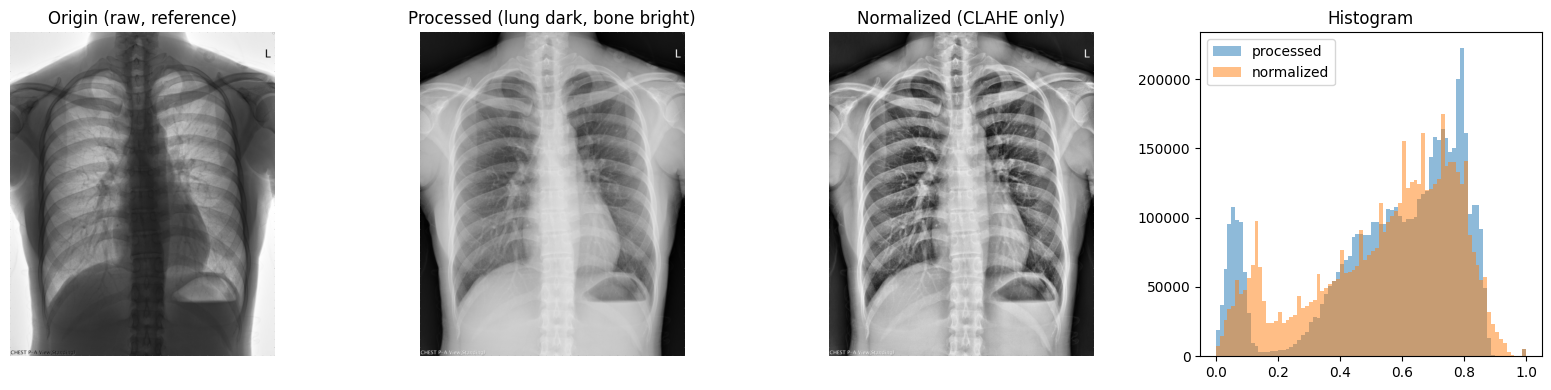

In [15]:
test_dcm = "/kaggle/input/hwk05-data/hwk05_data/train/normal/image/220.dcm"
visualize_normalization(test_dcm)


In [16]:
origin, clahe_img, norm_img = X_ray_normalization(test_dcm)
print(norm_img.min(), norm_img.max())


0.0 1.0


In [17]:
import os
import matplotlib.pyplot as plt

def save_train_images(
    df,
    base_path,
    output_dir,
    progress_step=50,
    split_name="train"   # "train" or "val"
):
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)

    n = len(df)

    for i, idx in enumerate(df.index):
        try:
            img_id   = df.at[idx, "ID"]
            category = df.at[idx, "category"]
            rel_path = df.at[idx, "ImagePath"]

            # 修正路徑
            if isinstance(rel_path, str) and (rel_path.startswith("/") or rel_path.startswith("\\")):
                rel_path = rel_path[1:]

            dcm_path = os.path.join(base_path, rel_path)

            # ✅ 新版 normalization（CLAHE-only）
            origin, proc, norm_img = X_ray_normalization(dcm_path)

            if norm_img is None:
                print(f"❌ 第 {i+1} 張 ({img_id}) 正規化失敗，略過")
                continue

            # 分類資料夾
            cat_dir = os.path.join(split_dir, str(category))
            os.makedirs(cat_dir, exist_ok=True)

            out_path = os.path.join(cat_dir, f"{img_id}.jpg")

            # 存 CLAHE normalized 圖
            plt.imsave(out_path, norm_img, cmap="gray")

        except KeyError as e:
            print(f"❌ 欄位錯誤：{e}，請確認 df 有 'ID', 'category', 'ImagePath'")
        except Exception as e:
            print(f"❌ 第 {i+1} 張 ({img_id}) 發生錯誤：{e}")

        if (i + 1) % progress_step == 0:
            print(f"✅ [{split_name}] 已處理 {i+1}/{n} 張影像")

    print(f"🎉 [{split_name}] 所有影像處理完成！ total={n}")


In [34]:
output_dir = "/kaggle/working/norm_images"

save_train_images(train_df, base_path, output_dir, split_name="train")
save_train_images(val_df,   base_path, output_dir, split_name="val")



✅ [train] 已處理 50/360 張影像
✅ [train] 已處理 100/360 張影像
✅ [train] 已處理 150/360 張影像
✅ [train] 已處理 200/360 張影像
✅ [train] 已處理 250/360 張影像
✅ [train] 已處理 300/360 張影像
✅ [train] 已處理 350/360 張影像
🎉 [train] 所有影像處理完成！ total=360
✅ [val] 已處理 50/91 張影像
🎉 [val] 所有影像處理完成！ total=91


In [18]:
import os
import matplotlib.pyplot as plt

def save_test_images(df, base_path, output_dir, progress_step=50):
    """
    Save normalized test images (CLAHE-only pipeline)
    """
    test_dir = os.path.join(output_dir, "test")
    os.makedirs(test_dir, exist_ok=True)

    n = len(df)

    for i, idx in enumerate(df.index):
        try:
            img_id = df.at[idx, "ID"]
            rel_path = df.at[idx, "ImagePath"]

            # 修正絕對路徑問題
            if isinstance(rel_path, str) and (rel_path.startswith("/") or rel_path.startswith("\\")):
                rel_path = rel_path[1:]

            dcm_path = os.path.join(base_path, rel_path)

            # ✅ 新介面：只回傳 3 個
            origin, proc, norm_img = X_ray_normalization(dcm_path)

            if norm_img is None:
                print(f"❌ 第 {i+1} 張 ({img_id}) 正規化失敗，略過")
                continue

            out_path = os.path.join(test_dir, f"{img_id}.jpg")

            # 存 normalized 影像
            plt.imsave(out_path, norm_img, cmap="gray")

        except KeyError as e:
            print(f"❌ 欄位錯誤：{e}，請確認 df 有 'ID' 與 'ImagePath'")
        except Exception as e:
            print(f"❌ 第 {i+1} 張 ({img_id}) 發生錯誤：{e}")

        if (i + 1) % progress_step == 0:
            print(f"✅ 已處理 {i+1}/{n} 張測試影像")

    print("🎉 測試影像全部處理完成！")


In [20]:
# 先轉一次 UTF-8
orig_test   = "/kaggle/input/hwk05-data/hwk05_data/test.csv"
utf8_test   = "/kaggle/working/test_utf8.csv"

convert_to_utf8(orig_test, utf8_test)

# 再讀轉好的 UTF-8 檔
test_df = pd.read_csv(utf8_test, encoding="utf-8")

base_path = "/kaggle/input/hwk05-data/hwk05_data/test"
output_dir = "/kaggle/working/norm_images"

save_test_images(test_df, base_path, output_dir)


偵測到原始編碼：ascii
轉換成功！已輸出：/kaggle/working/test_utf8.csv
✅ 已處理 50/113 張測試影像
✅ 已處理 100/113 張測試影像
🎉 測試影像全部處理完成！


In [21]:
categories_list = [
    'normal',
    'cardiac_hypertrophy',
    'aortic_atherosclerosis_calcification',
    'aortic_curvature',
    'intercostal_pleural_thickening',
    'lung_field_infiltration',
    'degenerative_joint_disease_of_the_thoracic_spine',
    'scoliosis'
]


In [22]:
def add_class_id_column(df, categories_list):
    """
    根據 categories_list 建立類別 → ID 映射，並在 df 中加入 class_id 欄位。
    
    參數:
    df : pandas DataFrame，需包含 'category' 欄位
    categories_list : list，類別名稱依固定順序
    
    回傳:
    更新後的 DataFrame（包含 class_id 欄位）
    """

    # 1. 建立 label → id 的字典
    label2class = {cat: idx for idx, cat in enumerate(categories_list)}
    
    # 印出字典以確認
    print("label2class 映射：")
    for k, v in label2class.items():
        print(f"  {k} → {v}")

    # 2. 新增 class_id 欄位
    df = df.copy()  # 保險起見不改原 df
    df['class_id'] = df['category'].map(label2class)

    # 檢查是否有類別沒對應到 ID
    if df['class_id'].isnull().any():
        missing = df[df['class_id'].isnull()]['category'].unique()
        print("\n⚠ 注意：以下類別沒有出現在 categories_list 中：")
        print(missing)

    return df


In [23]:
df_with_class = add_class_id_column(df_with_bbox, categories_list)
df_with_class.head()


label2class 映射：
  normal → 0
  cardiac_hypertrophy → 1
  aortic_atherosclerosis_calcification → 2
  aortic_curvature → 3
  intercostal_pleural_thickening → 4
  lung_field_infiltration → 5
  degenerative_joint_disease_of_the_thoracic_spine → 6
  scoliosis → 7


,ID,category,Width,Height,Filename,ImagePath,MarkPath,xmin,ymin,xmax,ymax,class_id
0,TDR04_20180315_075734,normal,2328,2344,220_97.dcm,normal/image/220_97.dcm,normal/mark/220_97.dcm.jpg,0,0,0,0,0
1,TDR04_20180315_080518,normal,2472,2560,220_94.dcm,normal/image/220_94.dcm,normal/mark/220_94.dcm.jpg,0,0,0,0,0
2,TDR04_20180315_081322,normal,2312,2496,220_93.dcm,normal/image/220_93.dcm,normal/mark/220_93.dcm.jpg,0,0,0,0,0
3,TDR04_20180315_081746,normal,2448,2584,220_92.dcm,normal/image/220_92.dcm,normal/mark/220_92.dcm.jpg,0,0,0,0,0
4,TDR04_20180315_082113,normal,2144,2384,220_91.dcm,normal/image/220_91.dcm,normal/mark/220_91.dcm.jpg,0,0,0,0,0


In [24]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# 需要：pip install -q scikit-multilearn
from skmultilearn.model_selection import iterative_train_test_split


def _infer_patient_id_from_name(name: str, take_parts=2) -> str:
    base = os.path.basename(str(name))
    stem = os.path.splitext(base)[0]
    parts = stem.split("_")
    if len(parts) >= take_parts:
        return "_".join(parts[:take_parts])
    return stem


def split_by_patient_id_iterative(
    df: pd.DataFrame,
    test_size=0.2,
    random_state=42,        # iterative_train_test_split 本身不吃 random_state，但我們會先 shuffle 病人順序
    patient_from="auto",    # "auto" | "patient_id" | "Filename" | "ImagePath"
    take_parts=2
):
    """
    病人層級 multi-label iterative stratification split (train/val)
    - 同一病人的所有資料只會在 train 或 val 其中一邊
    - 以病人持有的多疾病 (multi-hot) 做分層
    """

    df = df.copy()

    # ---------- 0) make patient_id ----------
    if patient_from == "patient_id":
        if "patient_id" not in df.columns:
            raise KeyError("df has no 'patient_id'")
        df["patient_id"] = df["patient_id"].astype(str)

    elif patient_from == "Filename":
        if "Filename" not in df.columns:
            raise KeyError("df has no 'Filename'")
        df["patient_id"] = df["Filename"].apply(lambda x: _infer_patient_id_from_name(x, take_parts=take_parts))

    elif patient_from == "ImagePath":
        if "ImagePath" not in df.columns:
            raise KeyError("df has no 'ImagePath'")
        df["patient_id"] = df["ImagePath"].apply(lambda x: _infer_patient_id_from_name(x, take_parts=take_parts))

    else:  # auto
        if "patient_id" in df.columns:
            df["patient_id"] = df["patient_id"].astype(str)
        elif "Filename" in df.columns:
            df["patient_id"] = df["Filename"].apply(lambda x: _infer_patient_id_from_name(x, take_parts=take_parts))
        elif "ImagePath" in df.columns:
            df["patient_id"] = df["ImagePath"].apply(lambda x: _infer_patient_id_from_name(x, take_parts=take_parts))
        else:
            raise KeyError("Cannot infer patient_id. df must contain one of: patient_id, Filename, ImagePath")

    # ---------- 1) categories -> class_id ----------
    categories = [
        "normal",
        "cardiac_hypertrophy",
        "aortic_atherosclerosis_calcification",
        "aortic_curvature",
        "intercostal_pleural_thickening",
        "lung_field_infiltration",
        "degenerative_joint_disease_of_the_thoracic_spine",
        "scoliosis",
    ]
    cat2id = {c: i for i, c in enumerate(categories)}

    if "category" not in df.columns:
        raise KeyError("df must contain 'category' column")

    df["class_id"] = df["category"].map(cat2id)
    if df["class_id"].isna().any():
        bad = df.loc[df["class_id"].isna(), "category"].unique().tolist()
        raise ValueError(f"Unknown categories found in df['category']: {bad}")

    # ---------- 2) patient -> multi-label set ----------
    # 每個病人擁有哪些 class_id（去重）
    patient_to_labels = (
        df.groupby("patient_id")["class_id"]
        .apply(lambda s: sorted(set(int(x) for x in s.values)))
        .to_dict()
    )

    patient_ids = np.array(list(patient_to_labels.keys()), dtype=object)

    # shuffle 病人順序（iterative_train_test_split 不吃 random_state，所以我們先 shuffle）
    rng = np.random.default_rng(random_state)
    rng.shuffle(patient_ids)

    # 建 multi-hot
    # 這裡用固定 class 數 (len(categories)) 最穩
    n_classes = len(categories)
    Y = np.zeros((len(patient_ids), n_classes), dtype=int)
    for i, pid in enumerate(patient_ids):
        for cid in patient_to_labels[pid]:
            Y[i, cid] = 1

    # ---------- 3) iterative train/test split ----------
    # X 必須是 2D array
    X = patient_ids.reshape(-1, 1)

    X_train, Y_train, X_val, Y_val = iterative_train_test_split(X, Y, test_size=test_size)

    train_pids = set(X_train.ravel().tolist())
    val_pids   = set(X_val.ravel().tolist())

    train_df = df[df["patient_id"].isin(train_pids)].copy()
    val_df   = df[df["patient_id"].isin(val_pids)].copy()

    return train_df, val_df


def summarize_split(train_df: pd.DataFrame, val_df: pd.DataFrame):
    def count_images_and_instances(df):
        # 你 df 可能每列=一個 bbox
        if "image_id" in df.columns:
            n_img = df["image_id"].nunique()
        elif "Filename" in df.columns:
            n_img = df["Filename"].nunique()
        elif "ImagePath" in df.columns:
            n_img = df["ImagePath"].nunique()
        else:
            n_img = np.nan
        n_inst = len(df)
        return n_img, n_inst

    tr_img, tr_inst = count_images_and_instances(train_df)
    va_img, va_inst = count_images_and_instances(val_df)

    print(f"[train] images={tr_img}, instances={tr_inst}")
    print(f"[val]   images={va_img}, instances={va_inst}")

    print("\n[val class counts]")
    print(val_df["category"].value_counts())


In [25]:
# 先裝套件（Kaggle 只要跑一次）
!pip install -q scikit-multilearn

train_df, val_df = split_by_patient_id_iterative(
    df,
    test_size=0.2,
    random_state=42,
    patient_from="auto",   # 或 "Filename"/"ImagePath"/"patient_id"
    take_parts=2
)

summarize_split(train_df, val_df)


[train] images=219, instances=361
[val]   images=57, instances=90

[val class counts]
category
normal                                              16
aortic_atherosclerosis_calcification                14
lung_field_infiltration                             14
degenerative_joint_disease_of_the_thoracic_spine    12
scoliosis                                           12
aortic_curvature                                    10
cardiac_hypertrophy                                  6
intercostal_pleural_thickening                       6
Name: count, dtype: int64


In [26]:
import pandas as pd

df = pd.read_csv("/kaggle/working/train_with_bbox.csv")

need = ["xmin","ymin","xmax","ymax"]
print("missing bbox cols:", [c for c in need if c not in df.columns])


missing bbox cols: []


In [27]:
train_df, val_df = split_by_patient_id_iterative(df)

print("train patients:", train_df["patient_id"].nunique(), "rows:", len(train_df))
print("val   patients:", val_df["patient_id"].nunique(), "rows:", len(val_df))

overlap = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
print("overlap size:", len(overlap))


train patients: 222 rows: 360
val   patients: 54 rows: 91
overlap size: 0


In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def visualize_and_validate_split(train_df, val_df, label_column='category'):
    """
    視覺化與驗證 train/val split:
    1. 確認病人 ID 無交集
    2. 類別分布可視化 (bar chart)
    3. 類別統計與百分比 table
    """

    print("=== 1. 檢查病人 ID 是否有資料外洩 (data leakage) ===")

    train_pids = set(train_df['patient_id'].unique())
    val_pids   = set(val_df['patient_id'].unique())

    inter = train_pids & val_pids
    if len(inter) == 0:
        print("✔ 病人 ID 無重疊（安全）")
    else:
        print("❌ 發現重複的病人 ID：", inter)

    print(f"訓練集病人數：{len(train_pids)}")
    print(f"驗證集病人數：{len(val_pids)}")
    print(f"訓練集樣本數：{len(train_df)}")
    print(f"驗證集樣本數：{len(val_df)}\n")

    # ============================
    # 2. 類別分布視覺化
    # ============================

    print("=== 2. 類別分布視覺化 (Train vs Val) ===")

    train_counts = train_df[label_column].value_counts().sort_index()
    val_counts   = val_df[label_column].value_counts().sort_index()

    categories = sorted(set(train_counts.index) | set(val_counts.index))

    # align 兩個 series 以確保順序一致
    train_counts = train_counts.reindex(categories, fill_value=0)
    val_counts   = val_counts.reindex(categories, fill_value=0)

    x = np.arange(len(categories))
    width = 0.35

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, train_counts, width, label='Train')
    plt.bar(x + width/2, val_counts,   width, label='Val')

    plt.xticks(x, categories, rotation=40, ha='right')
    plt.ylabel("Sample Count")
    plt.title("Train vs Validation Class Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================
    # 3. 類別統計 table
    # ============================

    print("\n=== 3. 類別統計（數量 + 百分比） ===")

    total_train = len(train_df)
    total_val   = len(val_df)

    stats = []

    for cat in categories:
        tr = train_counts[cat]
        va = val_counts[cat]

        stats.append({
            'category': cat,
            'train_count': tr,
            'train_%': round(tr / total_train * 100, 2),
            'val_count': va,
            'val_%': round(va / total_val * 100, 2)
        })

    stats_df = pd.DataFrame(stats)
    print(stats_df.to_string(index=False))

    return stats_df


=== 1. 檢查病人 ID 是否有資料外洩 (data leakage) ===
✔ 病人 ID 無重疊（安全）
訓練集病人數：222
驗證集病人數：54
訓練集樣本數：360
驗證集樣本數：91

=== 2. 類別分布視覺化 (Train vs Val) ===


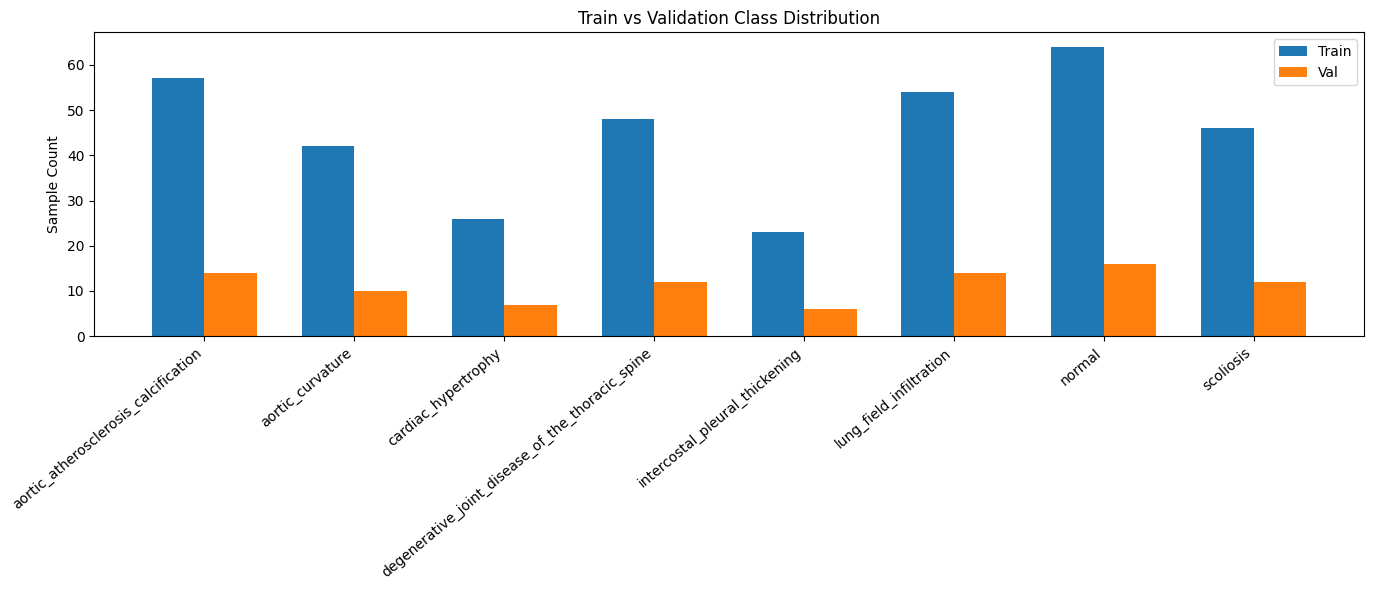


=== 3. 類別統計（數量 + 百分比） ===
                                        category  train_count  train_%  val_count  val_%
            aortic_atherosclerosis_calcification           57    15.83         14  15.38
                                aortic_curvature           42    11.67         10  10.99
                             cardiac_hypertrophy           26     7.22          7   7.69
degenerative_joint_disease_of_the_thoracic_spine           48    13.33         12  13.19
                  intercostal_pleural_thickening           23     6.39          6   6.59
                         lung_field_infiltration           54    15.00         14  15.38
                                          normal           64    17.78         16  17.58
                                       scoliosis           46    12.78         12  13.19


In [29]:
stats_df = visualize_and_validate_split(train_df, val_df, label_column='category')


In [30]:
import pandas as pd
import numpy as np

def dataset_summary(df):
    # 每列=一個 bbox（你目前就是這樣）
    n_inst = len(df)
    # 推估 image key
    if "image_id" in df.columns:
        img_key = "image_id"
    elif "Filename" in df.columns:
        img_key = "Filename"
    elif "ImagePath" in df.columns:
        img_key = "ImagePath"
    else:
        img_key = None

    n_img = df[img_key].nunique() if img_key else np.nan
    n_pid = df["patient_id"].nunique() if "patient_id" in df.columns else np.nan

    print(f"images: {n_img}")
    print(f"instances(bboxes): {n_inst}")
    print(f"patients: {n_pid}")
    print("\n[class instance counts]")
    print(df["category"].value_counts())

# 先確保 df 有 patient_id（你 split function 會加）
tmp = df.copy()
_ = split_by_patient_id_iterative(tmp, test_size=0.2, random_state=42, patient_from="auto", take_parts=2)
# 上面那行會回傳 train_df/val_df，但 tmp 內不會保留 patient_id，所以我們自己加一次：
tmp["patient_id"] = tmp["Filename"].apply(lambda x: _infer_patient_id_from_name(x, take_parts=2)) if "Filename" in tmp.columns else tmp["ImagePath"].apply(lambda x: _infer_patient_id_from_name(x, take_parts=2))

dataset_summary(tmp)


images: 276
instances(bboxes): 451
patients: 276

[class instance counts]
category
normal                                              80
aortic_atherosclerosis_calcification                71
lung_field_infiltration                             68
degenerative_joint_disease_of_the_thoracic_spine    60
scoliosis                                           58
aortic_curvature                                    52
cardiac_hypertrophy                                 33
intercostal_pleural_thickening                      29
Name: count, dtype: int64


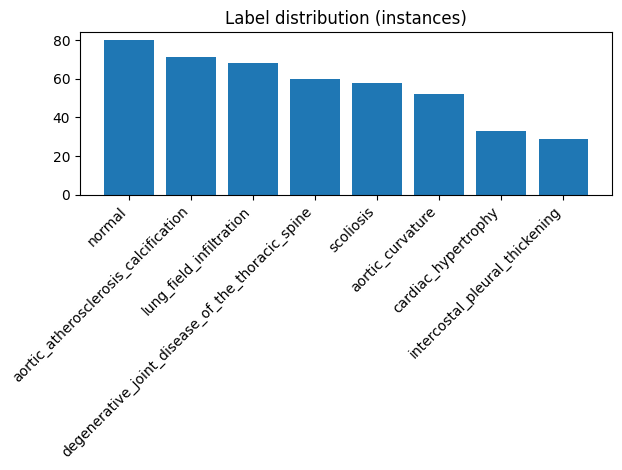

In [31]:
import matplotlib.pyplot as plt

counts = df["category"].value_counts().sort_values(ascending=False)
plt.figure()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Label distribution (instances)")
plt.tight_layout()
plt.show()


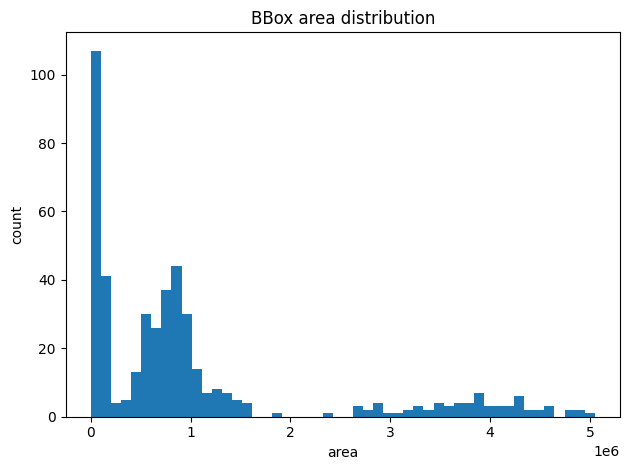

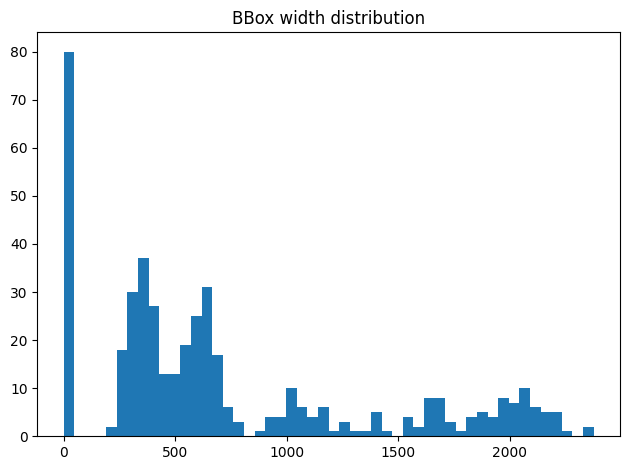

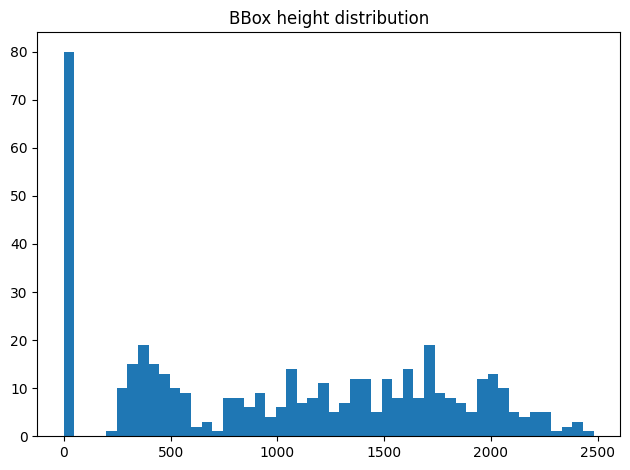

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def infer_bbox_cols(df):
    cand_sets = [
        ("xmin","xmax","ymin","ymax"),
        ("x1","x2","y1","y2"),
        ("XMin","XMax","YMin","YMax")
    ]
    for cols in cand_sets:
        if all(c in df.columns for c in cols):
            return cols
    raise KeyError("Cannot find bbox columns in df (need xmin/xmax/ymin/ymax or x1/x2/y1/y2).")

xmin,xmax,ymin,ymax = infer_bbox_cols(df)
w = (df[xmax] - df[xmin]).astype(float)
h = (df[ymax] - df[ymin]).astype(float)
area = w*h

plt.figure()
plt.hist(area.replace([np.inf,-np.inf], np.nan).dropna(), bins=50)
plt.title("BBox area distribution")
plt.xlabel("area")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(w.dropna(), bins=50)
plt.title("BBox width distribution")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(h.dropna(), bins=50)
plt.title("BBox height distribution")
plt.tight_layout()
plt.show()


In [35]:
import json
from datetime import date


def create_coco_json(df, categories_list, output_path):
    """
    將標註 DataFrame 轉成 COCO 格式並存成 json 檔。

    需要欄位：
      - ID, category, Width, Height, xmin, ymin, xmax, ymax
    """

    # ---------------- info ----------------
    coco = {}
    coco["info"] = {
        "description": "Chest X-ray disease detection dataset",
        "version": "1.0",
        "year": date.today().year,
        "date_created": date.today().isoformat()
    }
    coco["licenses"] = []

    # ---------------- categories ----------------
    categories = []
    category_name_to_id = {}

    for idx, cat in enumerate(categories_list):
        if cat == "normal":
            continue  # normal 不當作 detection 類別
        cat_id = idx  # 使用在 categories_list 中的 index（1~7）
        categories.append({
            "id": cat_id,
            "name": cat,
            "supercategory": "chest_disease"
        })
        category_name_to_id[cat] = cat_id

    coco["categories"] = categories

    # ---------------- images ----------------
    images = []
    image_id_map = {}  # 字串 ID → 數字 image_id

    unique_image_ids = df["ID"].unique()

    for idx, img_id in enumerate(unique_image_ids):
        row = df[df["ID"] == img_id].iloc[0]  # 同一張影像寬高都一樣，取第一列
        category = row["category"]
        img_dict = {
            "id": int(idx),
            "file_name": f"{category}/{img_id}.jpg",
            "width": int(row["Width"]),
            "height": int(row["Height"])
        }
        images.append(img_dict)
        image_id_map[img_id] = int(idx)

    coco["images"] = images

    # ---------------- annotations ----------------
    annotations = []
    ann_id = 0

    for _, row in df.iterrows():
        cat_name = row["category"]

        # normal 類別不建立 bbox annotation
        if cat_name == "normal":
            continue

        if cat_name not in category_name_to_id:
            # 防呆：如果有未知類別，直接略過或可以 print 出來
            print(f"⚠ 未知類別，略過 annotation：{cat_name}")
            continue

        image_id = image_id_map[row["ID"]]
        category_id = category_name_to_id[cat_name]

        xmin = float(row["xmin"])
        ymin = float(row["ymin"])
        xmax = float(row["xmax"])
        ymax = float(row["ymax"])

        width = xmax - xmin
        height = ymax - ymin

        if width <= 0 or height <= 0:
            print(f"⚠ 非法 bbox（寬或高 <= 0），略過：ID={row['ID']}")
            continue

        ann = {
            "id": int(ann_id),
            "image_id": int(image_id),
            "category_id": int(category_id),
            "bbox": [xmin, ymin, width, height],
            "area": float(width * height),
            "iscrowd": 0,
            "segmentation": []
        }

        annotations.append(ann)
        ann_id += 1

    coco["annotations"] = annotations

    # ---------------- 儲存 json ----------------
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=4)

    print(f"✅ COCO JSON 已儲存：{output_path}")
    print(f"  images: {len(images)}")
    print(f"  annotations: {len(annotations)}")
    print(f"  categories: {len(categories)}")


In [36]:
categories_list = [
    'normal',
    'cardiac_hypertrophy',
    'aortic_atherosclerosis_calcification',
    'aortic_curvature',
    'intercostal_pleural_thickening',
    'lung_field_infiltration',
    'degenerative_joint_disease_of_the_thoracic_spine',
    'scoliosis'
]

train_json_path = "/kaggle/working/coco_train.json"
create_coco_json(train_df, categories_list, train_json_path)

val_json_path = "/kaggle/working/coco_val.json"
create_coco_json(val_df, categories_list, val_json_path)

✅ COCO JSON 已儲存：/kaggle/working/coco_train.json
  images: 291
  annotations: 296
  categories: 7
✅ COCO JSON 已儲存：/kaggle/working/coco_val.json
  images: 86
  annotations: 75
  categories: 7


In [37]:
import os

def generate_train_val_coco(train_df, val_df, categories_list, output_dir):
    """
    產生 train / val 的 COCO JSON，並印出統計資訊。
    - 會呼叫前面定義好的 create_coco_json()
    - COCO 中只包含非 'normal' 類別
    """

    os.makedirs(output_dir, exist_ok=True)

    train_json_path = os.path.join(output_dir, "annotations_train.json")
    val_json_path   = os.path.join(output_dir, "annotations_val.json")

    # 1. 產生 COCO JSON
    create_coco_json(train_df, categories_list, train_json_path)
    create_coco_json(val_df,   categories_list, val_json_path)

    # 2. 印出統計資訊（排除 normal）
    def print_stats(name, df):
        print(f"\n=== {name} 統計 ===")
        n_images = df["ID"].nunique()
        # 非 normal 的標註數
        df_non_normal = df[df["category"] != "normal"]
        n_ann = len(df_non_normal)

        print(f"{name} 影像數（unique ID）: {n_images}")
        print(f"{name} 標註數（非 normal）: {n_ann}")
        print(f"{name} 類別分布：")

        # 類別計數（排除 normal）
        counts = df_non_normal["category"].value_counts().sort_index()
        for cat in counts.index:
            print(f"  {cat}: {counts[cat]}")

    print_stats("Train", train_df)
    print_stats("Val",   val_df)

    print(f"\n✅ 已輸出 COCO 標註至資料夾：{output_dir}")
    print(f"  - {train_json_path}")
    print(f"  - {val_json_path}")


In [38]:
output_dir = "/kaggle/working/coco_annotations"

generate_train_val_coco(train_df, val_df, categories_list, output_dir)


✅ COCO JSON 已儲存：/kaggle/working/coco_annotations/annotations_train.json
  images: 291
  annotations: 296
  categories: 7
✅ COCO JSON 已儲存：/kaggle/working/coco_annotations/annotations_val.json
  images: 86
  annotations: 75
  categories: 7

=== Train 統計 ===
Train 影像數（unique ID）: 291
Train 標註數（非 normal）: 296
Train 類別分布：
  aortic_atherosclerosis_calcification: 57
  aortic_curvature: 42
  cardiac_hypertrophy: 26
  degenerative_joint_disease_of_the_thoracic_spine: 48
  intercostal_pleural_thickening: 23
  lung_field_infiltration: 54
  scoliosis: 46

=== Val 統計 ===
Val 影像數（unique ID）: 86
Val 標註數（非 normal）: 75
Val 類別分布：
  aortic_atherosclerosis_calcification: 14
  aortic_curvature: 10
  cardiac_hypertrophy: 7
  degenerative_joint_disease_of_the_thoracic_spine: 12
  intercostal_pleural_thickening: 6
  lung_field_infiltration: 14
  scoliosis: 12

✅ 已輸出 COCO 標註至資料夾：/kaggle/working/coco_annotations
  - /kaggle/working/coco_annotations/annotations_train.json
  - /kaggle/working/coco_annotations/ann

In [39]:
import json
import numpy as np


def validate_coco_json(json_path, verbose=True):
    """
    驗證 COCO 標註 JSON 是否合理。

    檢查項目：
    - 必要 keys: info, images, annotations, categories
    - image_id 唯一且連續 (0 ~ N-1)
    - annotation_id 唯一
    - 每個 annotation 的 image_id 存在於 images
    - 每個 annotation 的 category_id 存在於 categories
    - bbox 格式正確 (4 個正數)
    - bbox 不超出影像範圍
    """

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    ok = True
    errors = []

    # 1. keys
    required_keys = ["info", "images", "annotations", "categories"]
    for k in required_keys:
        if k not in data:
            ok = False
            errors.append(f"缺少必要 key: '{k}'")

    images = data.get("images", [])
    annotations = data.get("annotations", [])
    categories = data.get("categories", [])

    if verbose:
        print(f"=== 驗證 {json_path} ===")
        print(f"images: {len(images)}, annotations: {len(annotations)}, categories: {len(categories)}")

    # 2. image_id 唯一且連續
    image_ids = [img["id"] for img in images]
    if len(image_ids) != len(set(image_ids)):
        ok = False
        errors.append("image_id 存在重複值")

    if len(image_ids) > 0:
        sorted_ids = sorted(image_ids)
        expected_ids = list(range(len(sorted_ids)))
        if sorted_ids != expected_ids:
            ok = False
            errors.append(f"image_id 非連續 0~N-1，實際最小={sorted_ids[0]}, 最大={sorted_ids[-1]}")

    # 建 map: image_id -> (width, height)
    img_size_map = {img["id"]: (img["width"], img["height"]) for img in images}

    # 3. annotation_id 唯一
    ann_ids = [ann["id"] for ann in annotations]
    if len(ann_ids) != len(set(ann_ids)):
        ok = False
        errors.append("annotation_id 存在重複值")

    # 4. category_id set
    category_ids = {cat["id"] for cat in categories}

    # 5 & 6. 檢查每個 annotation
    for ann in annotations:
        img_id = ann.get("image_id")
        cat_id = ann.get("category_id")
        bbox = ann.get("bbox", [])

        # 4-1: image_id 存在
        if img_id not in img_size_map:
            ok = False
            errors.append(f"annotation {ann['id']} 的 image_id={img_id} 不存在於 images")
            continue

        # 4-2: category_id 存在
        if cat_id not in category_ids:
            ok = False
            errors.append(f"annotation {ann['id']} 的 category_id={cat_id} 不存在於 categories")

        # 5: bbox 格式
        if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
            ok = False
            errors.append(f"annotation {ann['id']} 的 bbox 格式錯誤：{bbox}")
            continue

        x, y, w, h = bbox

        # bbox 元素必須是數字，且 w,h>0; x,y>=0
        if not all(isinstance(v, (int, float)) for v in bbox):
            ok = False
            errors.append(f"annotation {ann['id']} 的 bbox 含非數值：{bbox}")
            continue

        if w <= 0 or h <= 0 or x < 0 or y < 0:
            ok = False
            errors.append(f"annotation {ann['id']} 的 bbox 非正數或座標為負：{bbox}")
            continue

        # 6: bbox 不超出影像範圍
        img_w, img_h = img_size_map[img_id]
        if x + w > img_w + 1e-3 or y + h > img_h + 1e-3:
            ok = False
            errors.append(
                f"annotation {ann['id']} 的 bbox 超出影像範圍：bbox={bbox}, image_size=({img_w}, {img_h})"
            )

    # 輸出結果
    if verbose:
        if ok:
            print("✅ 驗證通過，未發現明顯問題。")
        else:
            print("❌ 驗證失敗，發現以下問題：")
            # 只列前幾個錯誤避免太長
            for e in errors[:20]:
                print("  -", e)
            if len(errors) > 20:
                print(f"  ... 等共 {len(errors)} 個問題")

    return ok


In [40]:
train_json = "/kaggle/working/coco_annotations/annotations_train.json"
val_json   = "/kaggle/working/coco_annotations/annotations_val.json"

ok_train = validate_coco_json(train_json)
ok_val   = validate_coco_json(val_json)

print("train json ok?", ok_train)
print("val json ok?", ok_val)


=== 驗證 /kaggle/working/coco_annotations/annotations_train.json ===
images: 291, annotations: 296, categories: 7
✅ 驗證通過，未發現明顯問題。
=== 驗證 /kaggle/working/coco_annotations/annotations_val.json ===
images: 86, annotations: 75, categories: 7
✅ 驗證通過，未發現明顯問題。
train json ok? True
val json ok? True


In [41]:
!pip -q install ultralytics

import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.4 MB/s eta 0:00:00a 0:00:01
torch: 2.8.0+cu126
cuda available: True
GPU: Tesla T4


In [42]:
import os

# === ROOT ===
DATA_ROOT = "/kaggle/working"

# === IMAGE DIRS ===
IMG_DIR_TRAIN = os.path.join(DATA_ROOT, "norm_images", "train")
IMG_DIR_VAL   = os.path.join(DATA_ROOT, "norm_images", "val")

# === COCO ANNOTATIONS ===
ANN_TRAIN = os.path.join(DATA_ROOT, "coco_train.json")
ANN_VAL   = os.path.join(DATA_ROOT, "coco_val.json")

# === 7 disease classes (NO normal) ===
CLASS_NAMES = [
    "cardiac_hypertrophy",
    "aortic_atherosclerosis_calcification",
    "aortic_curvature",
    "intercostal_pleural_thickening",
    "lung_field_infiltration",
    "degenerative_joint_disease_of_the_thoracic_spine",
    "scoliosis",
]

print("IMG_DIR_TRAIN exists:", os.path.isdir(IMG_DIR_TRAIN))
print("IMG_DIR_VAL exists:", os.path.isdir(IMG_DIR_VAL))
print("ANN_TRAIN exists:", os.path.exists(ANN_TRAIN))
print("ANN_VAL exists:", os.path.exists(ANN_VAL))


IMG_DIR_TRAIN exists: True
IMG_DIR_VAL exists: True
ANN_TRAIN exists: True
ANN_VAL exists: True


In [43]:
import json
import os
import shutil
from pathlib import Path

def _safe_link_or_copy(src, dst):
    if os.path.exists(dst):
        return
    try:
        os.link(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def coco_to_yolo_by_catid(
    ann_path: str,
    src_img_dir: str,
    out_img_dir: str,
    out_lab_dir: str,
):
    with open(ann_path, "r") as f:
        coco = json.load(f)

    # image info
    img_info = {im["id"]: im for im in coco["images"]}

    # ✅ category id -> yolo index (sort by id)
    cats_sorted = sorted(coco["categories"], key=lambda c: c["id"])  # [1..7]
    catid_to_yolo = {c["id"]: i for i, c in enumerate(cats_sorted)}  # 1->0, 2->1, ..., 7->6
    print("catid_to_yolo:", catid_to_yolo)
    print("cat names order:", [c["name"] for c in cats_sorted])

    # group annotations
    anns_by_img = {}
    for ann in coco["annotations"]:
        anns_by_img.setdefault(ann["image_id"], []).append(ann)

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lab_dir, exist_ok=True)

    n_images, n_boxes = 0, 0

    for img_id, im in img_info.items():
        fn = im["file_name"]
        W, H = float(im["width"]), float(im["height"])

        src = os.path.join(src_img_dir, fn)
        if not os.path.exists(src):
            src2 = os.path.join(src_img_dir, os.path.basename(fn))
            if not os.path.exists(src2):
                continue
            src = src2

        dst_img = os.path.join(out_img_dir, os.path.basename(fn))
        _safe_link_or_copy(src, dst_img)

        stem = Path(dst_img).stem
        lab_path = os.path.join(out_lab_dir, stem + ".txt")

        lines = []
        for ann in anns_by_img.get(img_id, []):
            cat_id = ann["category_id"]
            if cat_id not in catid_to_yolo:
                continue
            cls = catid_to_yolo[cat_id]

            x, y, w, h = ann["bbox"]  # COCO xywh absolute
            cx = (x + w/2.0) / W
            cy = (y + h/2.0) / H
            nw = w / W
            nh = h / H

            # clip
            cx = min(max(cx, 0.0), 1.0)
            cy = min(max(cy, 0.0), 1.0)
            nw = min(max(nw, 0.0), 1.0)
            nh = min(max(nh, 0.0), 1.0)
            if nw <= 0 or nh <= 0:
                continue

            lines.append(f"{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
            n_boxes += 1

        with open(lab_path, "w") as f:
            f.write("\n".join(lines))

        n_images += 1

    print(f"✅ Converted {ann_path} | images={n_images}, boxes={n_boxes}")


In [44]:
import os

YOLO_ROOT = "/kaggle/working/yolo_data"

YOLO_IMG_TRAIN = os.path.join(YOLO_ROOT, "images", "train")
YOLO_IMG_VAL   = os.path.join(YOLO_ROOT, "images", "val")
YOLO_LAB_TRAIN = os.path.join(YOLO_ROOT, "labels", "train")
YOLO_LAB_VAL   = os.path.join(YOLO_ROOT, "labels", "val")

os.makedirs(YOLO_IMG_TRAIN, exist_ok=True)
os.makedirs(YOLO_IMG_VAL, exist_ok=True)
os.makedirs(YOLO_LAB_TRAIN, exist_ok=True)
os.makedirs(YOLO_LAB_VAL, exist_ok=True)

coco_to_yolo_by_catid(ANN_TRAIN, IMG_DIR_TRAIN, YOLO_IMG_TRAIN, YOLO_LAB_TRAIN)
coco_to_yolo_by_catid(ANN_VAL,   IMG_DIR_VAL,   YOLO_IMG_VAL,   YOLO_LAB_VAL)



catid_to_yolo: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6}
cat names order: ['cardiac_hypertrophy', 'aortic_atherosclerosis_calcification', 'aortic_curvature', 'intercostal_pleural_thickening', 'lung_field_infiltration', 'degenerative_joint_disease_of_the_thoracic_spine', 'scoliosis']
✅ Converted /kaggle/working/coco_train.json | images=291, boxes=296
catid_to_yolo: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6}
cat names order: ['cardiac_hypertrophy', 'aortic_atherosclerosis_calcification', 'aortic_curvature', 'intercostal_pleural_thickening', 'lung_field_infiltration', 'degenerative_joint_disease_of_the_thoracic_spine', 'scoliosis']
✅ Converted /kaggle/working/coco_val.json | images=86, boxes=75


In [45]:
import yaml, json, os

with open(ANN_TRAIN, "r") as f:
    coco = json.load(f)
cats_sorted = sorted(coco["categories"], key=lambda c: c["id"])
names = {i: c["name"] for i, c in enumerate(cats_sorted)}  # 0..6

DATA_YAML_PATH = os.path.join(YOLO_ROOT, "data.yaml")
data_yaml = {
    "path": YOLO_ROOT,
    "train": "images/train",
    "val": "images/val",
    "names": names
}
with open(DATA_YAML_PATH, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(open(DATA_YAML_PATH, "r").read())


path: /kaggle/working/yolo_data
train: images/train
val: images/val
names:
  0: cardiac_hypertrophy
  1: aortic_atherosclerosis_calcification
  2: aortic_curvature
  3: intercostal_pleural_thickening
  4: lung_field_infiltration
  5: degenerative_joint_disease_of_the_thoracic_spine
  6: scoliosis



In [46]:
import os
from pathlib import Path

YOLO_ROOT = "/kaggle/working/yolo_data"
img_dirs = [Path(YOLO_ROOT) / "images" / "train", Path(YOLO_ROOT) / "images" / "val"]
lab_dirs = [Path(YOLO_ROOT) / "labels" / "train", Path(YOLO_ROOT) / "labels" / "val"]

def is_empty_label(txt_path: Path) -> bool:
    if not txt_path.exists():
        return True
    s = txt_path.read_text().strip()
    return len(s) == 0

removed = 0
kept = 0

for img_dir, lab_dir in zip(img_dirs, lab_dirs):
    if not img_dir.exists():
        continue
    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            continue

        lab_path = lab_dir / (img_path.stem + ".txt")

        # 空 label (或不存在 label) -> 當作 normal / negative，刪掉
        if is_empty_label(lab_path):
            try:
                img_path.unlink()
            except:
                pass
            if lab_path.exists():
                try:
                    lab_path.unlink()
                except:
                    pass
            removed += 1
        else:
            kept += 1

print(f"✅ Removed empty-label(normal) images: {removed}")
print(f"✅ Kept labeled images: {kept}")


✅ Removed empty-label(normal) images: 80
✅ Kept labeled images: 297


In [49]:
from ultralytics import YOLO
import os

dataset_yaml_path = "/kaggle/working/yolo_data/data.yaml"
assert os.path.exists(dataset_yaml_path)

model = YOLO("yolov8l.pt")

results = model.train(
    data=dataset_yaml_path,
    imgsz=1280,
    epochs=140,
    patience=40,
    batch=4,
    device=0,
    workers=2,
    seed=42,

    # ===== Optimizer =====
    optimizer="SGD",
    lr0=0.01,
    lrf=0.01,          # 後期 lr 降得更低，利於框精修
    momentum=0.937,
    weight_decay=0.0005,
    cos_lr=True,
    warmup_epochs=5.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    # ===== Aug（關鍵：早關重增強）=====
    mosaic=0.35,
    close_mosaic=60,   # ✅ 60 之後徹底關 mosaic（你之前關太晚/太早都會卡）
    mixup=0.0,
    copy_paste=0.0,    # ✅ 胸片先不要用，超容易製造假病灶→FP↑
    rect=False,        # ✅ 對偵測一般比較穩（你用 rect=True 常會卡）

    translate=0.02,
    scale=0.08,
    fliplr=0.5,
    flipud=0.0,

    # ===== loss weights（別撐太大，讓 conf 排序好一點）=====
    box=7.5,
    cls=0.55,          # ✅ 你 FP 多，cls 稍微拉回去一點，讓分類更在意
    dfl=1.5,

    amp=True,
    cache=False,

    project="/kaggle/working/yolo_runs",
    name="yolov8l_fpdown_finetune"
)

print("Best:", "/kaggle/working/yolo_runs/yolov8l_fpdown_finetune/weights/best.pt")


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=60, cls=0.55, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=140, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=0.35, multi_scale=False, name=yolov8l_fpdown_finetune2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=40, perspective=

Showing image: TDR01_20171120_110925.jpg


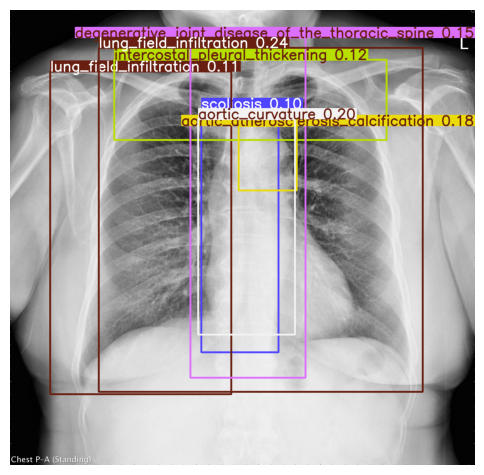

In [97]:
from ultralytics import YOLO
import random
import os
import matplotlib.pyplot as plt

# 1. 載入你剛訓練好的最佳權重
model = YOLO("/kaggle/working/yolo_runs/yolov8l_fpdown_finetune/weights/best.pt")

# 2. 從 val 圖片隨機抽一張
val_img_dir = "/kaggle/working/yolo_data/images/val"
img_files = [f for f in os.listdir(val_img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
img_name = random.choice(img_files)
img_path = os.path.join(val_img_dir, img_name)

print("Showing image:", img_name)

# 3. 推論（這裡才是真正「你會用的設定」）
results = model.predict(
    source=img_path,
    conf=0.05,     # ← 推論時提高信心門檻
    iou=0.5,         # ← NMS
    max_det=21,      # ← 7 類 × top3（跟你之前一致）
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False
)

# 4. 顯示結果
annotated = results[0].plot()  # 已經畫好框+類別
plt.figure(figsize=(6, 6))
plt.imshow(annotated)
plt.axis("off")
plt.show()


In [51]:
import torch
import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt

categories = model.names  # 跟 YOLO 完全一致

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [67]:
import numpy as np
import torch

@torch.no_grad()
def predict_yolo(
    image_path: str,
    model,
    conf: float = 0.05,
    iou: float = 0.3,
    topk_per_class: int = 3,
):
    """
    YOLOv8 prediction post-processing (Top-K per class + NMS already inside YOLO)

    Args:
        image_path: path to image (str)
        model: ultralytics.YOLO model
        conf: confidence threshold
        iou: NMS IoU threshold
        topk_per_class: keep top-K boxes per class

    Returns:
        boxes: np.ndarray (N,4) [x1,y1,x2,y2]
        classes: list[str]
        labels: list[int]
        scores: list[float]
    """

    # --- YOLO forward ---
    results = model(image_path, conf=conf, iou=iou)[0]

    if results.boxes is None or len(results.boxes) == 0:
        return np.zeros((0, 4), dtype=int), [], [], []

    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    labels = results.boxes.cls.cpu().numpy().astype(int)

    names = model.names

    # --- Top-K per class ---
    keep_indices = []
    for c in np.unique(labels):
        idxs = np.where(labels == c)[0]
        idxs = idxs[np.argsort(scores[idxs])[::-1]]  # sort desc
        keep_indices.extend(idxs[:topk_per_class])

    keep_indices = np.array(keep_indices, dtype=int)

    boxes = boxes[keep_indices]
    scores = scores[keep_indices]
    labels = labels[keep_indices]

    classes = [names[int(c)] for c in labels]

    return boxes.astype(int), classes, labels.tolist(), scores.tolist()


Classes:
0: cardiac_hypertrophy
1: aortic_atherosclerosis_calcification
2: aortic_curvature
3: intercostal_pleural_thickening
4: lung_field_infiltration
5: degenerative_joint_disease_of_the_thoracic_spine
6: scoliosis


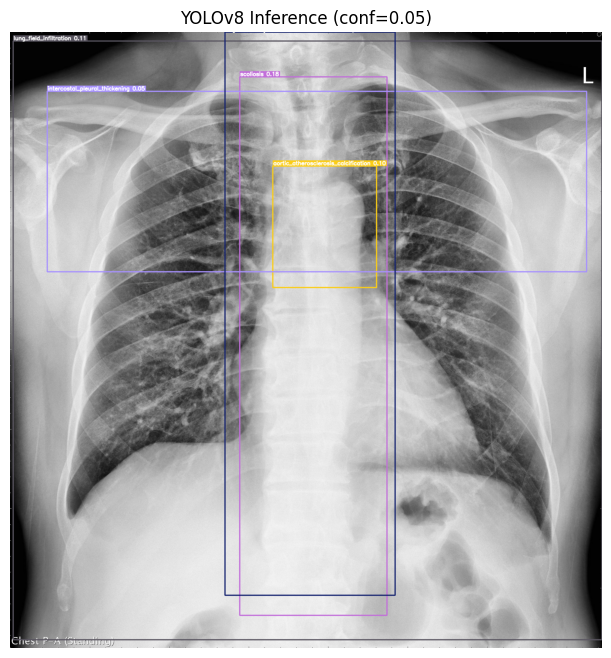

In [98]:
# ============================================================
# YOLOv8 Inference + Draw Boxes (FULL REPLACEMENT CELL)
# ============================================================

import torch
import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO

# -----------------------------
# 1. Load YOLOv8 model
# -----------------------------
CKPT_PATH = "/kaggle/working/yolo_runs/yolov8l_fpdown_finetune/weights/best.pt"  # ← 你的 best.pt
device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLO(CKPT_PATH)
model.to(device)

# -----------------------------
# 2. Class names (YOLO native)
# -----------------------------
# model.names is a dict: {0: 'xxx', 1: 'yyy', ...}
categories = model.names
num_classes = len(categories)

print("Classes:")
for k, v in categories.items():
    print(f"{k}: {v}")

# -----------------------------
# 3. Build colors (one per class)
# -----------------------------
def build_colors(num_classes, seed=42):
    rng = np.random.default_rng(seed)
    return rng.integers(0, 256, size=(num_classes, 3), dtype=np.uint8)

COLORS = build_colors(num_classes)

# -----------------------------
# 4. Draw boxes function
# -----------------------------
def draw_boxes(image, boxes, labels, scores):
    """
    image: np.ndarray (H,W,3) RGB
    boxes: (N,4) xyxy
    labels: (N,) int
    scores: (N,) float
    """
    img = image.copy()
    H, W = img.shape[:2]

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i].astype(int)
        cls_id = int(labels[i])
        score = scores[i]

        # clip
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W - 1, x2), min(H - 1, y2)

        color = COLORS[cls_id].tolist()
        color_bgr = (int(color[2]), int(color[1]), int(color[0]))

        # box
        cv2.rectangle(img, (x1, y1), (x2, y2), color_bgr, 3)

        # label
        label = f"{categories[cls_id]} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)

        cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw + 4, y1), color_bgr, -1)
        cv2.putText(
            img,
            label,
            (x1 + 2, y1 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

    return img

# -----------------------------
# 5. Single-image inference
# -----------------------------
def yolo_infer_and_show(
    image_path,
    conf_thres=0.05,   
    img_size=800
):
    assert os.path.exists(image_path), f"Image not found: {image_path}"

    # load image
    pil_img = Image.open(image_path).convert("RGB")
    img_np = np.array(pil_img)

    # inference
    results = model(
        pil_img,
        conf=conf_thres,
        imgsz=img_size,
        device=device,
        verbose=False
    )[0]

    if results.boxes is None or len(results.boxes) == 0:
        print("⚠️ No detections")
        plt.imshow(img_np)
        plt.axis("off")
        plt.show()
        return

    boxes = results.boxes.xyxy.cpu().numpy()
    labels = results.boxes.cls.cpu().numpy().astype(int)
    scores = results.boxes.conf.cpu().numpy()

    img_drawn = draw_boxes(img_np, boxes, labels, scores)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_drawn)
    plt.axis("off")
    plt.title(f"YOLOv8 Inference (conf={conf_thres})")
    plt.show()

# -----------------------------
# 6. RUN (example)
# -----------------------------
TEST_IMAGE = "/kaggle/working/norm_images/test/TDR01_20171106_111727.jpg"
yolo_infer_and_show(TEST_IMAGE, conf_thres=0.05)


In [99]:
from PIL import Image

img_path = "/kaggle/working/norm_images/test/TDR01_20171106_111727.jpg"

img = Image.open(img_path).convert("RGB")

results = model(
    img,
    conf=0.05,
    device=device,
    verbose=False
)[0]

# 取出結果
boxes = results.boxes.xyxy.cpu().numpy().astype(int)
labels = results.boxes.cls.cpu().numpy().astype(int)
scores = results.boxes.conf.cpu().numpy()
classes = [model.names[i] for i in labels]

print("boxes:", len(boxes))
print("labels:", labels)
print("classes:", classes)
print("scores:", scores)


boxes: 8
labels: [4 1 5 2 1 6 3 3]
classes: ['lung_field_infiltration', 'aortic_atherosclerosis_calcification', 'degenerative_joint_disease_of_the_thoracic_spine', 'aortic_curvature', 'aortic_atherosclerosis_calcification', 'scoliosis', 'intercostal_pleural_thickening', 'intercostal_pleural_thickening']
scores: [    0.34961      0.2492     0.15079     0.12711     0.11937    0.079816    0.077414    0.062485]


In [100]:
from PIL import Image

img = Image.open(img_path).convert("RGB")

results = model(
    img,
    conf=0.05,
    device=device,
    verbose=False
)[0]


In [101]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print("moved model to:", next(model.parameters()).device)


moved model to: cuda:0


In [102]:
# ====== install (Kaggle 通常已經有 ultralytics；沒有再開) ======
# !pip -q install ultralytics

import os
import time
import glob
import numpy as np
import pandas as pd
import cv2
import torch
from torchvision.ops import nms
from ultralytics import YOLO
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# 你的 best.pt 路徑（照你畫面右側 input 的 yolov8best）
YOLO_CKPT = "/kaggle/working/yolo_runs/yolov8l_fpdown_finetune/weights/best.pt"
model = YOLO(YOLO_CKPT)

# 類別表（直接用模型內建，最安全）
# 通常會是 dict: {0:'cardiac_hypertrophy', ...}
names = model.names
print("Classes:", names)


Classes: {0: 'cardiac_hypertrophy', 1: 'aortic_atherosclerosis_calcification', 2: 'aortic_curvature', 3: 'intercostal_pleural_thickening', 4: 'lung_field_infiltration', 5: 'degenerative_joint_disease_of_the_thoracic_spine', 6: 'scoliosis'}


In [103]:
def build_colors(num_classes, seed=42):
    rng = np.random.default_rng(seed)
    return rng.integers(0, 256, size=(num_classes, 3), dtype=np.uint8)  # RGB

COLORS = build_colors(num_classes=len(model.names), seed=42)

def draw_boxes_xyxy(img_bgr, boxes_xyxy, cls_ids, scores=None, names=None,
                    box_thickness=3, font_scale=0.9, text_thickness=2):
    """
    img_bgr: BGR uint8
    boxes_xyxy: (N,4) float/int in pixel coords
    cls_ids: (N,) int
    scores: (N,) float (optional)
    names: dict or list mapping cls_id -> name
    """
    out = img_bgr.copy()
    H, W = out.shape[:2]
    boxes = np.array(boxes_xyxy).reshape(-1, 4) if len(boxes_xyxy) else np.zeros((0,4))

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        x1 = int(max(0, min(W-1, round(x1))))
        y1 = int(max(0, min(H-1, round(y1))))
        x2 = int(max(0, min(W-1, round(x2))))
        y2 = int(max(0, min(H-1, round(y2))))

        c = int(cls_ids[i])
        rgb = COLORS[c] if 0 <= c < len(COLORS) else np.array([255,255,255], dtype=np.uint8)
        color = (int(rgb[2]), int(rgb[1]), int(rgb[0]))  # BGR

        cv2.rectangle(out, (x1,y1), (x2,y2), color, thickness=box_thickness)

        label = str(c)
        if names is not None:
            if isinstance(names, dict) and c in names:
                label = names[c]
            elif isinstance(names, (list, tuple)) and 0 <= c < len(names):
                label = names[c]

        if scores is not None:
            label = f"{label} {float(scores[i]):.3f}"

        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness)
        tx, ty = x1, y1 - 8
        if ty - th - bl < 0:
            ty = y1 + th + 8

        cv2.rectangle(out, (tx, ty - th - bl), (tx + tw, ty + bl), color, thickness=-1)
        cv2.putText(out, label, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale, (255,255,255), text_thickness, lineType=cv2.LINE_AA)

    return out



In [104]:
@torch.no_grad()
def yolo_predict_postprocess(
    image_bgr,
    model,
    conf=0.05,          # 先低一點多拿候選（你也可 0.1/0.2）
    iou=0.5,            # 先讓 YOLO 的 NMS 放寬（避免它先砍太多）
    topk_per_class=3,   # 你要的：每個疾病最多保留 3 個
    nms_iou=0.3         # 你要的：再做一次 class-wise NMS
):
    """
    Return:
      boxes_xyxy (N,4) float
      cls_ids (N,) int
      scores (N,) float
    """
    # Ultralytics YOLO inference
    res = model.predict(
        source=image_bgr,
        conf=conf,
        iou=iou,
        device=device,
        verbose=False
    )[0]

    if res.boxes is None or len(res.boxes) == 0:
        return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.int64), np.zeros((0,), dtype=np.float32)

    boxes = res.boxes.xyxy.detach().cpu().numpy().astype(np.float32)   # (M,4)
    scores = res.boxes.conf.detach().cpu().numpy().astype(np.float32)  # (M,)
    cls_ids = res.boxes.cls.detach().cpu().numpy().astype(np.int64)    # (M,)

    # --------- 1) per-class TopK ----------
    keep = []
    for c in np.unique(cls_ids):
        idx = np.where(cls_ids == c)[0]
        idx = idx[np.argsort(scores[idx])[::-1]]  # sort desc
        keep.extend(idx[:topk_per_class].tolist())
    keep = np.array(keep, dtype=np.int64)

    boxes_k = boxes[keep]
    scores_k = scores[keep]
    cls_k = cls_ids[keep]

    # --------- 2) class-wise NMS ----------
    final = []
    for c in np.unique(cls_k):
        idx = np.where(cls_k == c)[0]
        b = torch.tensor(boxes_k[idx], dtype=torch.float32)
        s = torch.tensor(scores_k[idx], dtype=torch.float32)
        k = nms(b, s, nms_iou).cpu().numpy().astype(np.int64)
        final.extend(idx[k].tolist())

    final = np.array(final, dtype=np.int64)
    boxes_f = boxes_k[final]
    scores_f = scores_k[final]
    cls_f = cls_k[final]

    # sort final by score desc (optional)
    order = np.argsort(scores_f)[::-1]
    return boxes_f[order], cls_f[order], scores_f[order]


In [105]:
import numpy as np
import torch
from torchvision.ops import nms
import cv2
import matplotlib.pyplot as plt

def _count_per_class(cls_ids):
    out = {}
    for c in cls_ids:
        out[int(c)] = out.get(int(c), 0) + 1
    return out

@torch.no_grad()
def compare_before_after_postprocess_verbose(
    image_path,
    model,
    conf_before=0.001,   # ✅ 先超低，讓 Before 爆框，才看得出後處理差
    iou_before=0.95,     # ✅ 放寬 YOLO 內建 NMS
    topk_per_class=3,
    nms_iou=0.3,
    figsize=(14,7)
):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    # ===== BEFORE (YOLO raw-ish) =====
    res0 = model.predict(
        source=img_bgr,
        conf=conf_before,
        iou=iou_before,
        device=device,
        verbose=False
    )[0]

    if res0.boxes is None or len(res0.boxes) == 0:
        boxes0 = np.zeros((0,4), dtype=np.float32)
        sc0    = np.zeros((0,), dtype=np.float32)
        cls0   = np.zeros((0,), dtype=np.int64)
    else:
        boxes0 = res0.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
        sc0    = res0.boxes.conf.detach().cpu().numpy().astype(np.float32)
        cls0   = res0.boxes.cls.detach().cpu().numpy().astype(np.int64)

    # ===== AFTER (TopK per class + class-wise NMS) =====
    # 1) topk per class
    keep = []
    for c in np.unique(cls0):
        idx = np.where(cls0 == c)[0]
        idx = idx[np.argsort(sc0[idx])[::-1]]
        keep.extend(idx[:topk_per_class].tolist())
    keep = np.array(keep, dtype=np.int64)

    boxes_k = boxes0[keep] if len(keep) else boxes0[:0]
    sc_k    = sc0[keep]    if len(keep) else sc0[:0]
    cls_k   = cls0[keep]   if len(keep) else cls0[:0]

    # 2) class-wise NMS
    final = []
    for c in np.unique(cls_k):
        idx = np.where(cls_k == c)[0]
        b = torch.tensor(boxes_k[idx], dtype=torch.float32)
        s = torch.tensor(sc_k[idx], dtype=torch.float32)
        k = nms(b, s, nms_iou).cpu().numpy().astype(np.int64)
        final.extend(idx[k].tolist())
    final = np.array(final, dtype=np.int64)

    boxes1 = boxes_k[final] if len(final) else boxes_k[:0]
    sc1    = sc_k[final]    if len(final) else sc_k[:0]
    cls1   = cls_k[final]   if len(final) else cls_k[:0]

    # ===== 印統計：你就知道為啥沒變 =====
    print(f"[BEFORE] total={len(boxes0)}  per-class={_count_per_class(cls0)}")
    print(f"[AFTER ] total={len(boxes1)}  per-class={_count_per_class(cls1)}")
    print(f"params: conf_before={conf_before}, iou_before={iou_before}, topk={topk_per_class}, nms_iou={nms_iou}")

    # ===== 畫圖 =====
    before_img = draw_boxes_xyxy(img_bgr, boxes0, cls0, sc0, names=model.names)
    after_img  = draw_boxes_xyxy(img_bgr, boxes1, cls1, sc1, names=model.names)

    fig, ax = plt.subplots(1,2, figsize=figsize)
    ax[0].imshow(cv2.cvtColor(before_img, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Before (more candidates)")
    ax[0].axis("off")

    ax[1].imshow(cv2.cvtColor(after_img, cv2.COLOR_BGR2RGB))
    ax[1].set_title("After (TopK/class + NMS)")
    ax[1].axis("off")

    plt.tight_layout()
    return fig


[BEFORE] total=41  per-class={4: 9, 1: 11, 5: 5, 2: 5, 6: 1, 3: 10}
[AFTER ] total=6  per-class={1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1}
params: conf_before=0.05, iou_before=0.95, topk=3, nms_iou=0.3


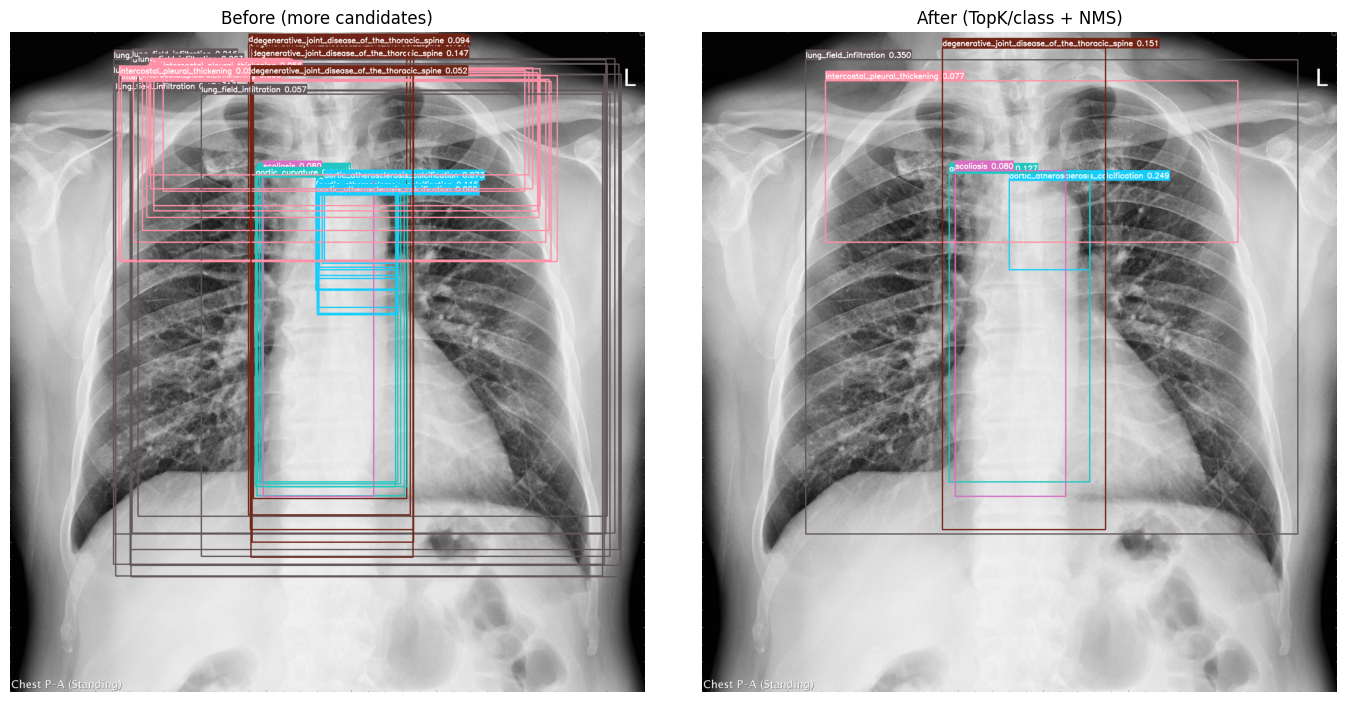

In [106]:
img = "/kaggle/working/norm_images/test/TDR01_20171106_111727.jpg"
fig = compare_before_after_postprocess_verbose(
    img, model,
    conf_before=0.05,
    iou_before=0.95,
    topk_per_class=3,
    nms_iou=0.3
)
plt.show()

In [78]:
# =========================================================
# YOLOv8 inference -> submission CSV
# + per-class conf threshold
# + per-class score multiplier (rebalance)
# + TopK/class + class-wise NMS
# + normalized coords in [0,1]
# + robust image-path match (Filename may be .dcm but dir contains .jpg)
# =========================================================

import os, re
import pandas as pd
import numpy as np
import torch
from torchvision.ops import nms

def _find_image_for_row(row, test_image_dir, filename_col=None):
    # 0) If ImagePath exists and is valid -> use it (or basename join)
    for c in ["ImagePath", "image_path", "path"]:
        if c in row and pd.notna(row[c]):
            p = str(row[c]).strip()
            cand1 = p
            cand2 = os.path.join(test_image_dir, os.path.basename(p))
            if os.path.exists(cand1):
                return cand1
            if os.path.exists(cand2):
                return cand2

    # 1) Candidate from Filename (may be .dcm)
    fn = None
    if filename_col is not None and filename_col in row and pd.notna(row[filename_col]):
        fn = str(row[filename_col]).strip()

    if fn:
        p = os.path.join(test_image_dir, os.path.basename(fn))
        if os.path.exists(p):
            return p

        # If .dcm but folder has .jpg -> try same stem with image extensions
        stem = os.path.splitext(os.path.basename(fn))[0]
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            p2 = os.path.join(test_image_dir, stem + ext)
            if os.path.exists(p2):
                return p2

    # 2) Use ID string to find matching image
    if "ID" in row and pd.notna(row["ID"]):
        id_str = str(row["ID"]).strip()

        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            p = os.path.join(test_image_dir, id_str + ext)
            if os.path.exists(p):
                return p

        # prefix match: ID_*.jpg
        try:
            files = os.listdir(test_image_dir)
        except FileNotFoundError:
            return None

        pat = re.compile(rf"^{re.escape(id_str)}.*\.(jpg|jpeg|png|bmp)$", re.IGNORECASE)
        for f in files:
            if pat.match(f):
                return os.path.join(test_image_dir, f)

    return None


def _postprocess_topk_nms(boxes_xyxy, scores, cls_ids, topk_per_class=3, nms_iou=0.3):
    if boxes_xyxy is None or len(boxes_xyxy) == 0:
        return (np.zeros((0, 4), dtype=np.float32),
                np.zeros((0,), dtype=np.float32),
                np.zeros((0,), dtype=np.int64))

    boxes = np.asarray(boxes_xyxy, dtype=np.float32)
    scores = np.asarray(scores, dtype=np.float32)
    cls_ids = np.asarray(cls_ids, dtype=np.int64)

    # TopK per class
    keep = []
    for c in np.unique(cls_ids):
        idx = np.where(cls_ids == c)[0]
        idx = idx[np.argsort(scores[idx])[::-1]]
        keep.extend(idx[:int(topk_per_class)].tolist())
    keep = np.array(keep, dtype=np.int64)

    boxes = boxes[keep]
    scores = scores[keep]
    cls_ids = cls_ids[keep]

    # class-wise NMS
    final = []
    for c in np.unique(cls_ids):
        idx = np.where(cls_ids == c)[0]
        b = torch.tensor(boxes[idx], dtype=torch.float32)
        s = torch.tensor(scores[idx], dtype=torch.float32)
        k = nms(b, s, float(nms_iou)).cpu().numpy().astype(np.int64)
        final.extend(idx[k].tolist())
    final = np.array(final, dtype=np.int64)

    return boxes[final], scores[final], cls_ids[final]


@torch.no_grad()
def generate_submission_csv_yolo(
    student_id: str,
    model,                         # ultralytics.YOLO(...) object
    test_csv_path: str,
    test_image_dir: str,
    out_csv_path: str = None,
    conf: float = 0.05,            # YOLO internal conf threshold (pre-filter)
    iou_before: float = 0.5,        # YOLO internal NMS iou (pre-filter)
    topk_per_class: int = 3,        # ✅ you want
    nms_iou: float = 0.3,           # ✅ you want
    device=None,

):
    """
    Output columns:
      ID, category, score, xmin, xmax, ymin, ymax
    where xmin/xmax/ymin/ymax are normalized to [0,1].
    """
    if out_csv_path is None:
        out_csv_path = f"{student_id}.csv"

    df = pd.read_csv(test_csv_path)

    filename_col = None
    for c in ["Filename", "filename"]:
        if c in df.columns:
            filename_col = c
            break

    if "ID" not in df.columns:
        raise KeyError(f"test.csv must contain 'ID'. Columns={list(df.columns)}")

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    rows = []
    missing = 0

    for _, row in df.iterrows():
        img_path = _find_image_for_row(row, test_image_dir, filename_col=filename_col)
        if img_path is None:
            missing += 1
            continue

        res = model.predict(
            source=img_path,
            conf=float(conf),
            iou=float(iou_before),
            device=device,
            verbose=False
        )[0]

        if res.boxes is None or len(res.boxes) == 0:
            continue

        boxes_px = res.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
        scores = res.boxes.conf.detach().cpu().numpy().astype(np.float32)
        cls_ids = res.boxes.cls.detach().cpu().numpy().astype(np.int64)

        # map cls_id -> class_name
        names = getattr(model, "names", None) or {}
        cls_names = np.array([names.get(int(cid), str(int(cid))) for cid in cls_ids], dtype=object)

        # TopK/class + class-wise NMS
        boxes_px, scores, cls_ids = _postprocess_topk_nms(
            boxes_px, scores, cls_ids,
            topk_per_class=topk_per_class,
            nms_iou=nms_iou
        )
        if len(boxes_px) == 0:
            continue

        # original image shape for normalization
        h0, w0 = res.orig_shape[:2]   # (H, W)

        img_id = str(row["ID"]).strip()

        for (x1, y1, x2, y2), sc, cid in zip(boxes_px, scores, cls_ids):
            x1n = float(np.clip(x1 / w0, 0.0, 1.0))
            x2n = float(np.clip(x2 / w0, 0.0, 1.0))
            y1n = float(np.clip(y1 / h0, 0.0, 1.0))
            y2n = float(np.clip(y2 / h0, 0.0, 1.0))

            cname = names.get(int(cid), str(int(cid))) if isinstance(names, dict) else str(int(cid))

            rows.append({
                "ID": img_id,
                "category": str(cname),
                "score": float(sc),
                "xmin": x1n,
                "xmax": x2n,
                "ymin": y1n,
                "ymax": y2n,
            })

    out_df = pd.DataFrame(rows, columns=["ID","category","score","xmin","xmax","ymin","ymax"])
    out_df.to_csv(out_csv_path, index=False)

    print(f"✅ Saved: {out_csv_path}  rows={len(out_df)}  missing_images={missing}  test_rows={len(df)}")
    return out_df


In [79]:
out_df = generate_submission_csv_yolo(
    student_id="314657010",
    model=model,
    test_csv_path="/kaggle/input/hwk05-data/hwk05_data/test.csv",
    test_image_dir="/kaggle/working/norm_images/test",
    out_csv_path="314657010.csv",
    conf=0.05,
    iou_before=0.5,
    topk_per_class=3,
    nms_iou=0.3,
)

out_df.head()



✅ Saved: 314657010.csv  rows=523  missing_images=0  test_rows=113


,ID,category,score,xmin,xmax,ymin,ymax
0,TDR02_20161123_145314,cardiac_hypertrophy,0.261126,0.405442,0.878662,0.340500,0.716024
1,TDR02_20161123_145314,aortic_atherosclerosis_calcification,0.179263,0.523489,0.656266,0.200886,0.359105
2,TDR02_20161123_145314,aortic_curvature,0.374757,0.380488,0.670625,0.196351,0.699234
3,TDR02_20161123_145314,lung_field_infiltration,0.299294,0.208865,0.964660,0.040174,0.784979
4,TDR02_20161123_145314,degenerative_joint_disease_of_the_thoracic_spine,0.111485,0.388386,0.660471,0.021082,0.755600


<Figure size 1000x400 with 0 Axes>

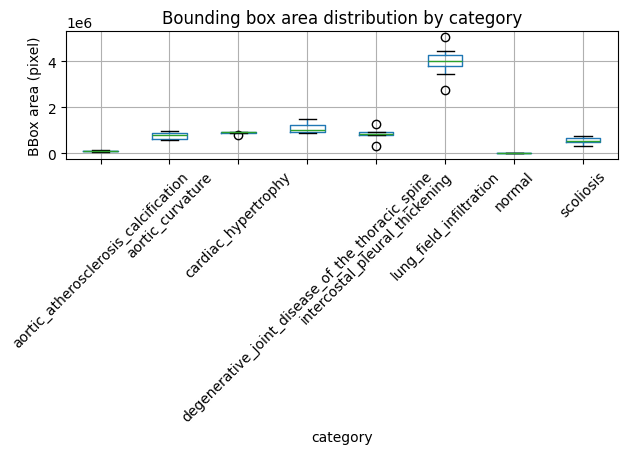

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df = val_df.copy()

df["bbox_area"] = (df["xmax"] - df["xmin"]) * (df["ymax"] - df["ymin"])

plt.figure(figsize=(10,4))
df.boxplot(column="bbox_area", by="category", rot=45)
plt.title("Bounding box area distribution by category")
plt.suptitle("")
plt.ylabel("BBox area (pixel)")
plt.tight_layout()
plt.show()


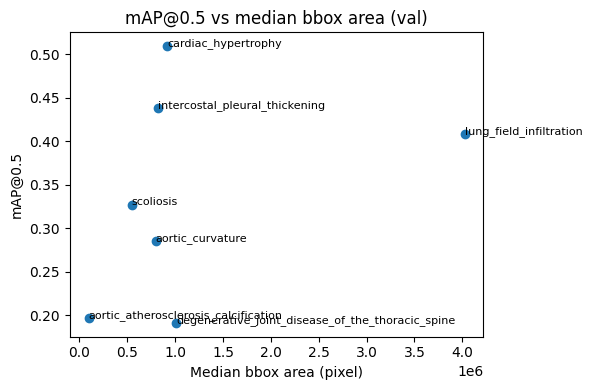

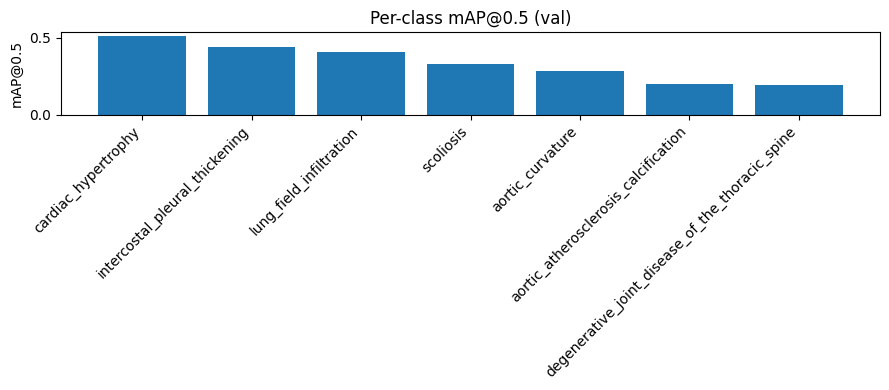

,category,count,median_area,iqr,mAP50
2,cardiac_hypertrophy,7,920000.0,39616.0,0.509
4,intercostal_pleural_thickening,6,818368.0,109952.0,0.438
5,lung_field_infiltration,14,4024064.0,455740.0,0.408
6,scoliosis,12,547584.0,175328.0,0.327
1,aortic_curvature,10,798736.0,241116.0,0.285
0,aortic_atherosclerosis_calcification,14,97600.0,30816.0,0.197
3,degenerative_joint_disease_of_the_thoracic_spine,12,1013376.0,294496.0,0.191


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) bbox 尺度統計（從 val_df）
df = val_df.copy()
df["bbox_area"] = (df["xmax"] - df["xmin"]) * (df["ymax"] - df["ymin"])

area_stats = df.groupby("category")["bbox_area"].agg(
    median_area="median",
    iqr=lambda s: np.percentile(s, 75) - np.percentile(s, 25),
    mean_area="mean",
    count="count"
).reset_index()

# 2) 手動填入：你的 YOLO 驗證結果（每類 mAP50）
#    把下面的數字改成你那張表的 mAP50（每類一個）
map50_dict = {
    "cardiac_hypertrophy": 0.509,
    "aortic_atherosclerosis_calcification": 0.197,
    "aortic_curvature": 0.285,
    "intercostal_pleural_thickening": 0.438,
    "lung_field_infiltration": 0.408,
    "degenerative_joint_disease_of_the_thoracic_spine": 0.191,
    "scoliosis": 0.327,
    # "normal": ???  # 如果你的表沒有 normal 的 mAP 就先不要填
}

map_df = pd.DataFrame(list(map50_dict.items()), columns=["category", "mAP50"])

# 3) 合併（尺度 + mAP）
merged = pd.merge(area_stats, map_df, on="category", how="inner")

# --- Figure A: mAP50 vs median bbox area（散點圖）---
plt.figure(figsize=(6,4))
plt.scatter(merged["median_area"], merged["mAP50"])
for _, r in merged.iterrows():
    plt.text(r["median_area"], r["mAP50"], r["category"], fontsize=8)

plt.xlabel("Median bbox area (pixel)")
plt.ylabel("mAP@0.5")
plt.title("mAP@0.5 vs median bbox area (val)")
plt.tight_layout()
plt.show()

# --- Figure B: 排序後的條圖（更好解釋）---
merged_sorted = merged.sort_values("mAP50", ascending=False)

plt.figure(figsize=(9,4))
plt.bar(merged_sorted["category"], merged_sorted["mAP50"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("mAP@0.5")
plt.title("Per-class mAP@0.5 (val)")
plt.tight_layout()
plt.show()

merged_sorted[["category","count","median_area","iqr","mAP50"]]


In [107]:
from ultralytics import YOLO
import os

best_pt = "/kaggle/working/yolo_runs/yolov8l_fpdown_finetune/weights/best.pt"
model = YOLO(best_pt)

metrics = model.val(
    data="/kaggle/working/yolo_data/data.yaml",
    imgsz=1280,
    conf=0.05,
    iou=0.5,
    save=True,
    save_txt=True,
    save_conf=True,
    plots=True        # ✅ 關鍵：強制輸出預測圖
)

print("val done.")


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 43,612,005 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3903.7±1053.6 MB/s, size: 469.8 KB)
val: Scanning /kaggle/working/yolo_data/labels/val.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 132.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.6s/it 13.0s3.8ss
                   all         70         75      0.218      0.864      0.337      0.211
   cardiac_hypertrophy          7          7      0.202      0.714      0.378      0.265
aortic_atherosclerosis_calcification         14         14      0.275          1      0.287       0.14
      aortic_curvature         10         10        0.2          1      0.292      0.202
intercostal_pleural_thickening          6          6      0.182      0.833      0.447        0.3
lung_field_i

In [94]:
# ================================
# Auto select bad cases for Error Analysis
# (FP / FN / Localization Error)
# ================================

import os
import numpy as np
import pandas as pd

# ====== 請確認這個路徑（YOLO val 的 labels 資料夾） ======
PRED_LABEL_DIR = "/kaggle/working/runs/detect/val3/labels"  # ← 若不同請改這行

assert os.path.exists(PRED_LABEL_DIR), "❌ 找不到 YOLO 預測 labels 資料夾"

# ====== 1) 準備 GT（Ground Truth） ======
gt = val_df.copy()

# 用 ID 當圖片識別（你資料裡已確認存在）
gt["img_stem"] = gt["ID"].astype(str)

gt = gt[["img_stem", "xmin", "ymin", "xmax", "ymax", "Width", "Height"]].copy()

# 每張圖的 GT bbox
gt_groups = gt.groupby("img_stem").apply(
    lambda d: d[["xmin","ymin","xmax","ymax"]].values.astype(float)
).to_dict()

# 每張圖的尺寸
img_wh = gt.groupby("img_stem").first()[["Width","Height"]].to_dict("index")


# ====== 2) 讀 YOLO 預測框 ======
def load_yolo_txt(path):
    arr = []
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) >= 6 else 1.0
            arr.append([xc,yc,w,h,conf])
    return np.array(arr, dtype=float) if arr else np.zeros((0,5), dtype=float)

pred = {}
for fn in os.listdir(PRED_LABEL_DIR):
    if fn.endswith(".txt"):
        stem = os.path.splitext(fn)[0]
        pred[stem] = load_yolo_txt(os.path.join(PRED_LABEL_DIR, fn))


# ====== 3) 工具函式 ======
def yolo_to_xyxy(norm_boxes, W, H):
    if len(norm_boxes)==0:
        return np.zeros((0,5), dtype=float)
    xc, yc, bw, bh, conf = norm_boxes.T
    x1 = (xc - bw/2) * W
    x2 = (xc + bw/2) * W
    y1 = (yc - bh/2) * H
    y2 = (yc + bh/2) * H
    return np.stack([x1,y1,x2,y2,conf], axis=1)

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
    inter = iw*ih
    area_a = max(0, ax2-ax1)*max(0, ay2-ay1)
    area_b = max(0, bx2-bx1)*max(0, by2-by1)
    union = area_a + area_b - inter + 1e-9
    return inter/union

def match_fp_fn(gt_boxes, pred_boxes_xyxy, iou_thr=0.5):
    G = len(gt_boxes)
    P = len(pred_boxes_xyxy)
    if G==0 and P==0:
        return 0,0,np.nan
    if G==0:
        return P,0,np.nan
    if P==0:
        return 0,G,np.nan

    matched_gt = set()
    ious = []

    for j in range(P):
        p = pred_boxes_xyxy[j,:4]
        best_iou, best_i = 0.0, -1
        for i in range(G):
            if i in matched_gt:
                continue
            v = iou_xyxy(gt_boxes[i], p)
            if v > best_iou:
                best_iou, best_i = v, i
        if best_iou >= iou_thr and best_i != -1:
            matched_gt.add(best_i)
            ious.append(best_iou)

    tp = len(matched_gt)
    fp = P - tp
    fn = G - tp
    mean_iou = float(np.mean(ious)) if ious else 0.0
    return fp, fn, mean_iou


# ====== 4) 計算每張圖的 FP / FN / mean IoU ======
rows = []

all_imgs = set(gt_groups.keys()) | set(pred.keys())

for img_id in all_imgs:
    gt_boxes = gt_groups.get(img_id, np.zeros((0,4), dtype=float))
    wh = img_wh.get(img_id, {"Width":1.0,"Height":1.0})
    W, H = float(wh["Width"]), float(wh["Height"])

    pred_norm = pred.get(img_id, np.zeros((0,5), dtype=float))
    pred_xyxy = yolo_to_xyxy(pred_norm, W, H)

    fp, fn, miou = match_fp_fn(gt_boxes, pred_xyxy, iou_thr=0.5)

    rows.append([img_id, len(gt_boxes), len(pred_xyxy), fp, fn, miou])

score_df = pd.DataFrame(
    rows,
    columns=["image_id","gt_n","pred_n","FP","FN","meanIoU"]
)


# ====== 5) 自動挑最爛 ======
worst_fn  = score_df.sort_values(["FN","FP"], ascending=False).head(5)
worst_fp  = score_df.sort_values(["FP","FN"], ascending=False).head(5)
worst_iou = score_df.sort_values(["meanIoU"], ascending=True).head(5)

print("=== Worst by FN (漏檢最多) ===")
display(worst_fn)

print("=== Worst by FP (誤檢最多) ===")
display(worst_fp)

print("=== Worst by mean IoU (定位最差) ===")
display(worst_iou)


=== Worst by FN (漏檢最多) ===


/tmp/ipykernel_55/3344051840.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gt_groups = gt.groupby("img_stem").apply(


,image_id,gt_n,pred_n,FP,FN,meanIoU
5,TDR02_20161123_093653,1,4,4,1,0.0
8,TDR01_20171212_085921,1,4,4,1,0.0
64,TDR01_20190318_101716,1,4,4,1,0.0
40,TDR04_20180301_094211,1,3,3,1,0.0
73,TDR01_20171122_142655,1,2,2,1,0.0


=== Worst by FP (誤檢最多) ===


,image_id,gt_n,pred_n,FP,FN,meanIoU
21,TDR01_20180509_155654,1,8,7,0,0.637232
38,TDR04_20180226_090403,1,7,6,0,0.691247
62,TDR02_20161118_151259,1,7,6,0,0.923166
74,TDR01_20171120_110925,1,7,6,0,0.540369
1,TDR01_20190312_165507,1,6,5,0,0.812057


=== Worst by mean IoU (定位最差) ===


,image_id,gt_n,pred_n,FP,FN,meanIoU
8,TDR01_20171212_085921,1,4,4,1,0.0
5,TDR02_20161123_093653,1,4,4,1,0.0
64,TDR01_20190318_101716,1,4,4,1,0.0
40,TDR04_20180301_094211,1,3,3,1,0.0
73,TDR01_20171122_142655,1,2,2,1,0.0
